# 📦 Procurement Analytics: Classification
---

*Model:*  Random Forest Classifier

*SDG:*  SDG 8: DECENT WORK AND ECONOMIC GROWTH

*Dataset:* Enterprise Procurement Orders (2022–2023)
https://www.kaggle.com/datasets/shahriarkabir/procurement-kpi-analysis-dataset

# **I. Business / Problem Understanding**

## **Analytical Objective**

Organizations depend on procurement and supplier management to ensure that materials and products are delivered on time, meet quality standards, and remain within budget. Procurement compliance, the degree to which purchase orders adhere to negotiated terms, quality thresholds, and delivery commitments that is a critical but often reactive concern. When procurement teams manage hundreds of orders across multiple suppliers and categories, it becomes difficult to manually identify risk before problems materialize.

The objective of this analysis is to apply **Classification (Supervised Machine Learning)** techniques to generate a compliance risk score for every purchase order, and use that score alongside order status signals, to answer three concrete business questions:

1. **Will an order be delayed?** — Identify orders with abnormally long lead times or unresolved pending status before they breach delivery commitments.
2. **Will an order be cancelled?** — Flag orders at high risk of cancellation so procurement managers can intervene early.
3. **Will a supplier become non-compliant?** — Detect suppliers whose order portfolio consistently generates high compliance risk, enabling proactive audits and contract reviews.

A single classification model is trained on historical procurement data using key performance indicators: negotiated savings rate, defective unit rate, lead time, order value, item category, supplier identity, and order status. The model's output (compliance risk score) serves as the shared foundation from which all three business predictions are derived.

By unifying these three predictions under one modeling pipeline, the classification system enables procurement managers to proactively flag high-risk orders, reducing costs, penalties, and supply chain disruptions.


## **Intended End Users**

The results of this classification analysis are designed to support several stakeholders within the organization:

* **Procurement Managers** — To receive early warnings on orders likely to be **delayed or cancelled**, enabling timely corrective action before deadlines are missed.
* **Supplier Relationship Officers** — To identify suppliers with recurring compliance issues and initiate structured performance reviews based on **non-compliance risk scores**.
* **Supply Chain Analysts** — To monitor and forecast **delay and cancellation risk** across the full procurement pipeline, supporting capacity and contingency planning.
* **Executive Decision Makers** — To receive aggregated **supplier risk rankings** that guide policy decisions around contract renewals, supplier diversification, and quality thresholds.

## **Business Value of Classification**

Training a classification model on historical procurement data creates a data-driven early warning system with three operational outputs. Rather than reviewing every order manually, the pipeline automatically scores incoming orders and surfaces actionable risk signals:

* **Predict Order Delays Early** — By flagging orders with high lead times or unresolved pending status, procurement teams can expedite shipments or negotiate revised delivery dates before SLA breaches occur.
* **Prevent Order Cancellations** — High-risk pending orders identified by the model can be escalated to managers for recovery actions such as re-sourcing or supplier substitution, avoiding lost inventory and cost overruns.
* **Strengthen Supplier Accountability** — Aggregating risk scores at the supplier level reveals which vendors consistently produce non-compliant orders, creating an objective basis for contract reviews and supplier audits.
* **Optimize Procurement Workflows** — Automating compliance risk scoring on incoming purchase orders reduces manual review time and allows teams to focus oversight resources on the orders that matter most.

# **II. Data Understanding**

## **Import Required Libraries**

In [93]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV)

# Scikit-learn: classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier

# Scikit-learn: evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, roc_curve, auc
)

# Imbalanced-learn: SMOTE for class imbalance
from imblearn.over_sampling import SMOTE

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Global settings
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

print("All libraries imported successfully.")

# GLOBAL STYLE — Blue Ocean Palette

BLUE = {
    'navy':   '#001D39',
    'dark':   '#0A4174',
    'mid':    '#49769F',
    'teal':   '#4E8EA2',
    'slate':  '#6EA2B3',
    'sky':    '#7BBDE8',
    'ice':    '#BDD8E9',
    'bg':     '#EEF5FB',
    'white':  '#F5FAFF',
}

CLUSTER_COLORS = ['#001D39','#0A4174','#49769F','#4E8EA2','#7BBDE8']

plt.rcParams.update({
    'figure.facecolor': BLUE['bg'],
    'axes.facecolor':   BLUE['white'],
    'axes.edgecolor':   BLUE['slate'],
    'axes.labelcolor':  BLUE['navy'],
    'axes.titlecolor':  BLUE['navy'],
    'axes.grid':        True,
    'axes.axisbelow':   True,
    'grid.color':       '#D6E8F5',
    'grid.linewidth':   0.6,
    'xtick.color':      BLUE['mid'],
    'ytick.color':      BLUE['mid'],
    'font.family':      'DejaVu Sans',
    'figure.dpi':       110,
})

def clean_ax(ax, grid_axis='y'):
    ax.spines[['top','right']].set_visible(False)
    ax.spines['left'].set_color(BLUE['ice'])
    ax.spines['bottom'].set_color(BLUE['ice'])
    ax.grid(axis=grid_axis, color='#D6E8F5', linewidth=0.6)
    ax.tick_params(labelsize=8.5)

All libraries imported successfully.


## **Load Dataset**

In [94]:
df = pd.read_csv('/content/sample_data/Procurement-KPI-Analysis-Dataset.csv')

print(f"Dataset loaded. Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset loaded. Shape: 777 rows x 11 columns


## **Describing the Data**

In [95]:
df.head()

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,NaN,Yes
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No


In [96]:
df.tail()

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
772,PO-00773,Delta_Logistics,2023-02-11,2023-02-20,Electronics,Delivered,1685,43.42,42.24,262.0,Yes
773,PO-00774,Alpha_Inc,2022-07-23,NaN,Office Supplies,Delivered,445,68.94,60.35,7.0,Yes
774,PO-00775,Gamma_Co,2022-03-19,2022-04-07,Raw Materials,Delivered,494,94.82,81.89,29.0,Yes
775,PO-00776,Beta_Supplies,2023-08-30,2023-09-11,MRO,Delivered,1306,21.05,18.27,128.0,Yes
776,PO-00777,Beta_Supplies,2023-12-09,2023-12-11,Office Supplies,Delivered,1988,105.20,93.23,187.0,Yes


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PO_ID             777 non-null    object 
 1   Supplier          777 non-null    object 
 2   Order_Date        777 non-null    object 
 3   Delivery_Date     690 non-null    object 
 4   Item_Category     777 non-null    object 
 5   Order_Status      777 non-null    object 
 6   Quantity          777 non-null    int64  
 7   Unit_Price        777 non-null    float64
 8   Negotiated_Price  777 non-null    float64
 9   Defective_Units   641 non-null    float64
 10  Compliance        777 non-null    object 
dtypes: float64(3), int64(1), object(7)
memory usage: 66.9+ KB


In [98]:
df.describe()

,Quantity,Unit_Price,Negotiated_Price,Defective_Units
count,777.000000,777.000000,777.000000,641.000000
mean,1094.660232,58.283822,53.660721,74.803432
std,647.844551,28.101315,26.094930,69.187870
min,51.000000,10.840000,9.270000,0.000000
25%,615.000000,33.290000,30.460000,26.000000
50%,1075.000000,58.950000,53.800000,49.000000
75%,1548.000000,83.130000,76.550000,100.000000
max,5000.000000,109.170000,107.390000,321.000000


## **Categorial Column Distribution**

In [99]:
for col in ['Supplier', 'Item_Category', 'Order_Status', 'Compliance']:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())
    print("-" * 35)


Supplier:
Supplier
Delta_Logistics    171
Epsilon_Group      166
Beta_Supplies      156
Gamma_Co           143
Alpha_Inc          141
-----------------------------------

Item_Category:
Item_Category
Office Supplies    174
MRO                164
Electronics        152
Packaging          148
Raw Materials      139
-----------------------------------

Order_Status:
Order_Status
Delivered              560
Pending                 81
Partially Delivered     73
Cancelled               63
-----------------------------------

Compliance:
Compliance
Yes    640
No     137
-----------------------------------


This data summary outlines the categorical distributions across 777 total procurement transactions, revealing a balanced spread among suppliers and item categories but a severe imbalance in order statuses and compliance. While transactions are evenly divided among the five main vendors (led by Delta_Logistics at 171) and five product categories (led by Office Supplies at 174), the operational metrics are heavily skewed. The vast majority of orders are successfully Delivered (560), leaving a combined total of 217 orders stuck as Pending, Partially Delivered, or Cancelled. Most critically, the target variable exhibits a stark 82% to 18% class imbalance, with 640 Compliant ("Yes") orders against just 137 Non-Compliant ("No") orders; this primary skew explains why baseline machine learning models struggle to isolate risk, as they naturally tend to memorize the overwhelming majority class.

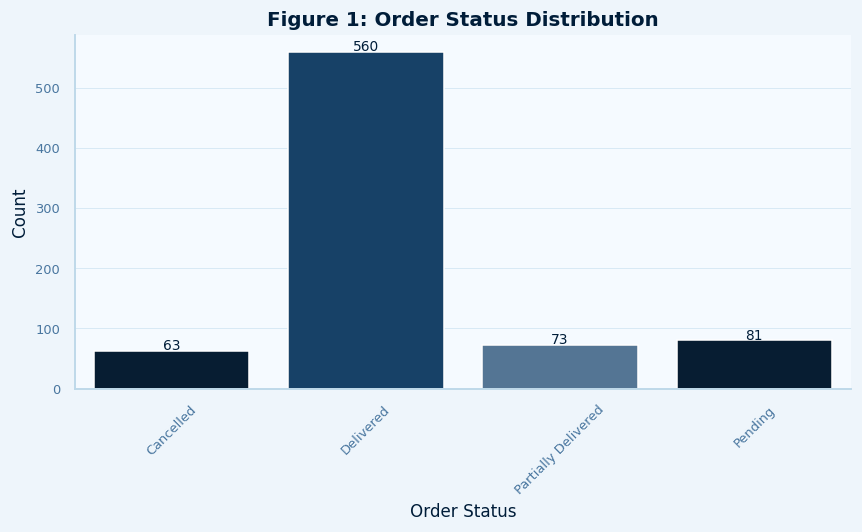

In [148]:
# ORDER STATUS DISTRIBUTION

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    x='Order_Status',
    data=df,
    palette=CLUSTER_COLORS
)

plt.title(
    'Figure 1: Order Status Distribution',
    fontsize=13,
    fontweight='bold',
    color=BLUE['navy']
)

plt.xlabel(
    'Order Status',
    fontsize=11,
    color=BLUE['navy']
)

plt.ylabel(
    'Count',
    fontsize=11,
    color=BLUE['navy']
)

plt.xticks(rotation=45)

# Apply Blue Ocean styling
clean_ax(ax)

# Add labels on bars
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha='center',
        fontsize=9,
        color=BLUE['navy']
    )

plt.tight_layout()
plt.show()

Fugure 1 illustrates a heavy operational imbalance across the four fulfillment statuses in the procurement dataset. The overwhelming majority of the 777 total transactions are successfully completed, with Delivered orders leading dramatically at 560. In contrast, active or failed operational states make up a much smaller fraction of the data: Pending orders account for 81, Partially Delivered orders sit at 73, and Cancelled transactions represent the lowest volume at 63. This distribution highlights that while the supply chain successfully finalizes most requests, the remaining 217 non-delivered orders serve as the vital operational pockets where potential compliance and delay risks are concentrated.

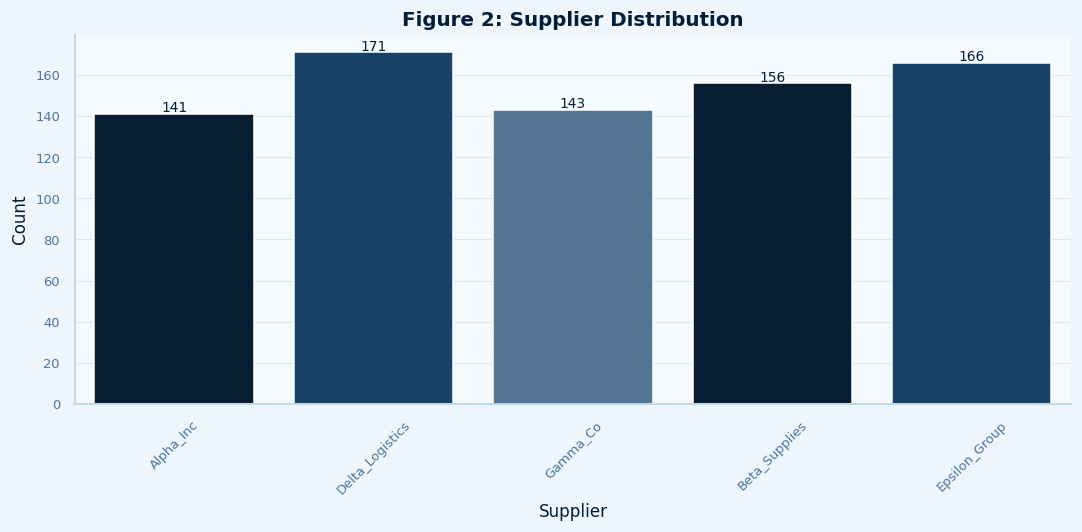

In [149]:
# SUPPLIER DISTRIBUTION

plt.figure(figsize=(10, 5))

ax = sns.countplot(
    x='Supplier',
    data=df,
    palette=CLUSTER_COLORS
)

plt.title(
    'Figure 2: Supplier Distribution',
    fontsize=13,
    fontweight='bold',
    color=BLUE['navy']
)

plt.xlabel(
    'Supplier',
    fontsize=11,
    color=BLUE['navy']
)

plt.ylabel(
    'Count',
    fontsize=11,
    color=BLUE['navy']
)

plt.xticks(rotation=45)

# Apply Blue Ocean styling
clean_ax(ax)

# Add labels on bars
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha='center',
        fontsize=9,
        color=BLUE['navy']
    )

plt.tight_layout()
plt.show()


This bar chart visualizes the order distribution across the five primary vendors in the dataset, showcasing a highly balanced procurement workload. Delta_Logistics leads with the highest volume at 171 orders, followed closely by Epsilon_Group at 166 orders and Beta_Supplies at 156 orders. The remaining transactions are evenly split between Gamma_Co (143 orders) and Alpha_Inc (141 orders). Because the purchasing volume is distributed relatively equally without a single vendor dominating the supply chain data, the dataset provides an excellent foundation for fair, unbiased benchmarking of supplier risk and compliance performance.

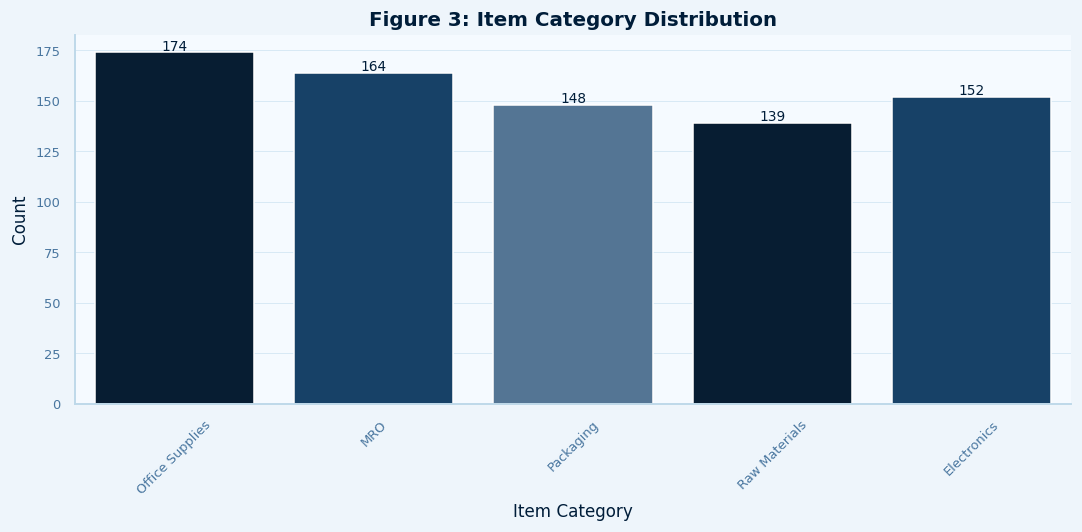

In [150]:
# ITEM CATEGORY DISTRIBUTION

plt.figure(figsize=(10, 5))

ax = sns.countplot(
    x='Item_Category',
    data=df,
    palette=CLUSTER_COLORS
)

plt.title(
    'Figure 3: Item Category Distribution',
    fontsize=13,
    fontweight='bold',
    color=BLUE['navy']
)

plt.xlabel(
    'Item Category',
    fontsize=11,
    color=BLUE['navy']
)

plt.ylabel(
    'Count',
    fontsize=11,
    color=BLUE['navy']
)

plt.xticks(rotation=45)

# Apply Blue Ocean styling
clean_ax(ax)

# Add labels on bars
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha='center',
        fontsize=9,
        color=BLUE['navy']
    )

plt.tight_layout()
plt.show()

This illustrates the distribution across the five purchasing categories in the dataset, totaling 777 orders. The procurement allocation is relatively uniform across segments, led by Office Supplies with 174 orders and MRO (Maintenance, Repair, and Operations) at 164 orders. Electronics follows as the median category with 152 orders, while Packaging and Raw Materials round out the lower end of the spectrum with 148 and 139 orders, respectively. This relatively balanced spread indicates that no single product category dominates the purchasing data, ensuring that any subsequent compliance or risk analysis is representative of a diverse mix of corporate inventory and supplies.

## **Exploratory Data Analysis**

### **Target Variable Distribution — Compliance**

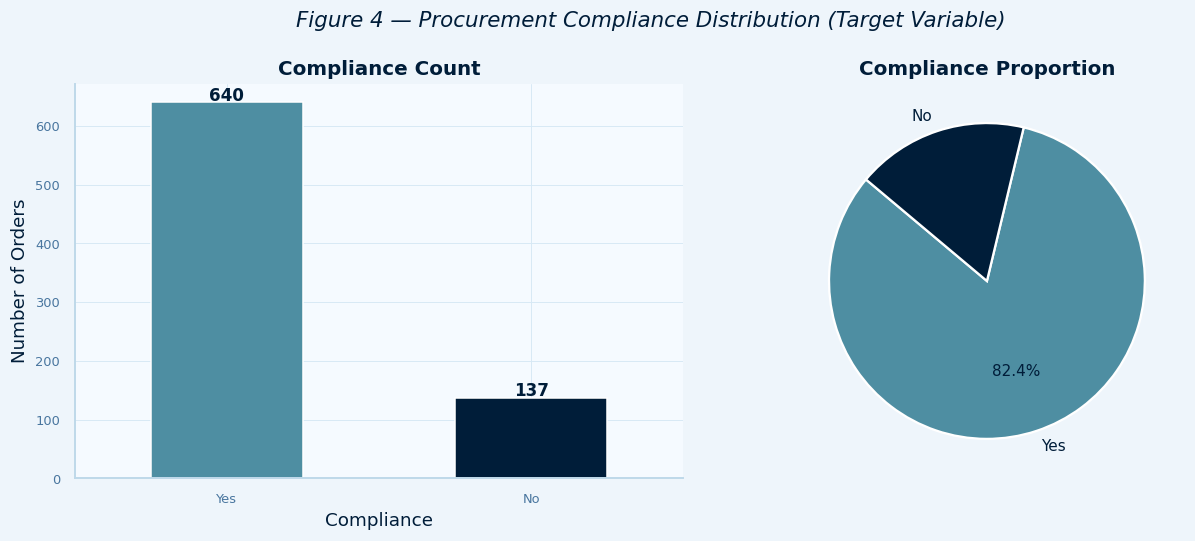

Class imbalance — Yes: 640 | No: 137
Non-Compliance Rate: 17.6%


In [151]:
compliance_counts = df['Compliance'].value_counts()

# Blue Ocean colors
colors = [BLUE['teal'], BLUE['navy']]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# BAR CHART

compliance_counts.plot(
    kind='bar',
    ax=axes[0],
    color=colors,
    edgecolor='white'
)

axes[0].set_title(
    'Compliance Count',
    fontsize=13,
    fontweight='bold'
)

axes[0].set_xlabel('Compliance')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=0)

# Apply custom style
clean_ax(axes[0])

# Add value labels
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(int(bar.get_height())),
        ha='center',
        fontsize=11,
        fontweight='bold',
        color=BLUE['navy']
    )

# PIE CHART

axes[1].pie(
    compliance_counts.values,
    labels=compliance_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops=dict(
        edgecolor='white',
        linewidth=1.5
    ),
    textprops={
        'color': BLUE['navy'],
        'fontsize': 10
    }
)

axes[1].set_title(
    'Compliance Proportion',
    fontsize=13,
    fontweight='bold',
    color=BLUE['navy']
)

# MAIN TITLE

plt.suptitle(
    'Figure 4 — Procurement Compliance Distribution (Target Variable)',
    fontsize=14,
    fontstyle='italic',
    color=BLUE['navy']
)

plt.tight_layout()
plt.show()


# SUMMARY STATISTICS

print(
    f"Class imbalance — Yes: {compliance_counts['Yes']} | "
    f"No: {compliance_counts['No']}"
)

print(
    f"Non-Compliance Rate: "
    f"{compliance_counts['No'] / len(df) * 100:.1f}%"
)

Figure 4 confirms a severe class imbalance within the dataset's target variable across 777 procurement orders. The bar chart and pie chart show that 640 orders are Compliant ("Yes"), accounting for an overwhelming 82.4% of the total volume. In contrast, only 137 orders are Non-Compliant ("No"), representing the remaining 17.6%. This stark distribution exposes a critical modeling challenge: because the data is heavily skewed toward successful transactions, standard machine learning classifiers will inherently bias toward predicting compliance, making hyperparameter tuning or class-weight adjustments essential to accurately isolate and detect the minority risk cases.

### **Order Status Distribution**

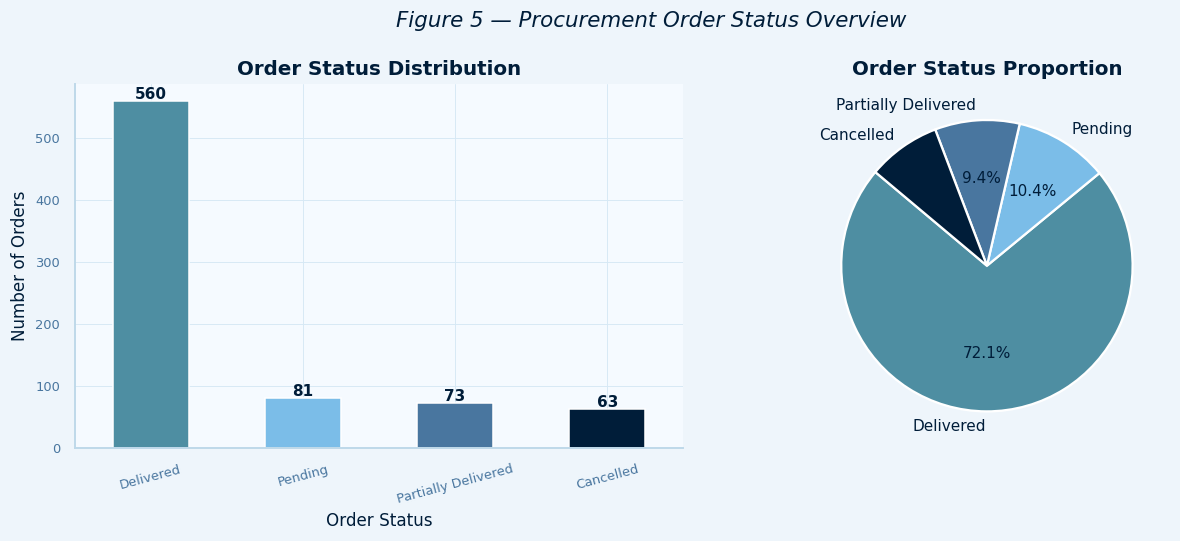

In [152]:
# EDA — ORDER STATUS DISTRIBUTION

status_counts = df['Order_Status'].value_counts()

# Blue Ocean palette colors
colors_status = [
    BLUE['teal'],
    BLUE['sky'],
    BLUE['mid'],
    BLUE['navy']
]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# BAR CHART

status_counts.plot(
    kind='bar',
    ax=axes[0],
    color=colors_status,
    edgecolor='white'
)

axes[0].set_title(
    'Order Status Distribution',
    fontsize=13,
    fontweight='bold',
    color=BLUE['navy']
)

axes[0].set_xlabel(
    'Order Status',
    fontsize=11,
    color=BLUE['navy']
)

axes[0].set_ylabel(
    'Number of Orders',
    fontsize=11,
    color=BLUE['navy']
)

axes[0].tick_params(axis='x', rotation=15)

# Apply Blue Ocean styling
clean_ax(axes[0])

# Add value labels
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(int(bar.get_height())),
        ha='center',
        fontsize=10,
        fontweight='bold',
        color=BLUE['navy']
    )

# PIE CHART

axes[1].pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors_status,
    startangle=140,
    wedgeprops=dict(
        edgecolor='white',
        linewidth=1.5
    ),
    textprops={
        'color': BLUE['navy'],
        'fontsize': 10
    }
)

axes[1].set_title(
    'Order Status Proportion',
    fontsize=13,
    fontweight='bold',
    color=BLUE['navy']
)

# MAIN TITLE

plt.suptitle(
    'Figure 5 — Procurement Order Status Overview',
    fontsize=14,
    fontstyle='italic',
    color=BLUE['navy']
)

plt.tight_layout()
plt.show()

This figure 5 provides an overview of procurement order statuses, highlighting that the vast majority of orders are successfully processed, with Delivered orders making up 72.1% (560 orders) of the total volume. The remaining active pipeline consists of Pending orders at 10.4% (81 orders) and Partially Delivered orders at 9.4% (73 orders). Cancelled orders represent the smallest segment at just 8.1% (63 orders), indicating a highly efficient overall fulfillment process with a low rate of disruption.

### **Compliance Rate by Supplier and Item Category**

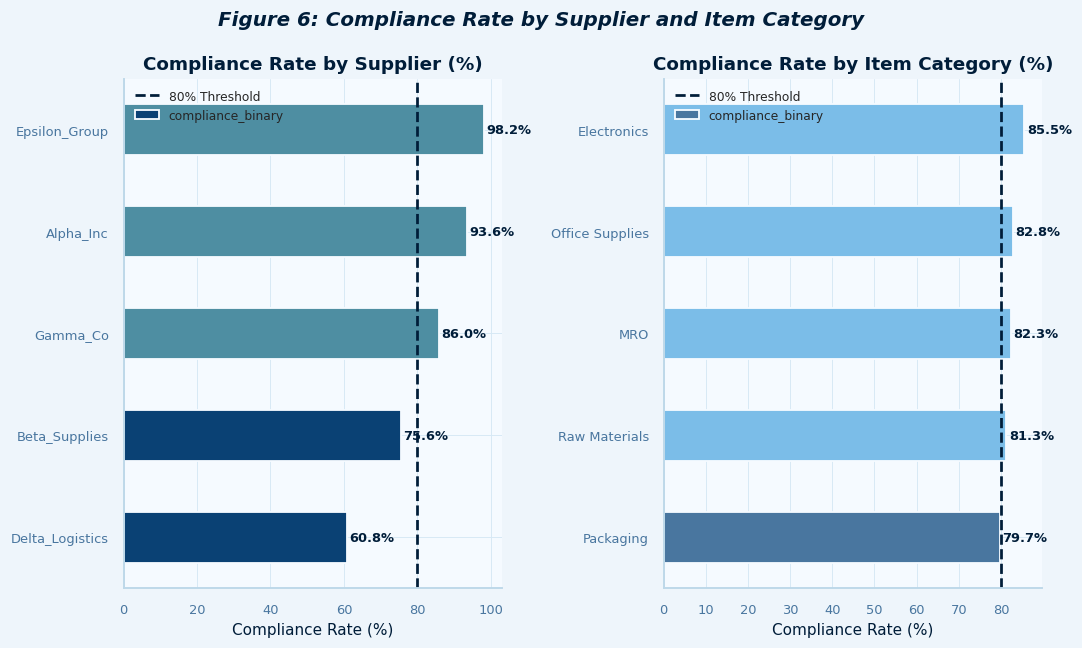

In [157]:
# Compliance Rate

df_temp = df.copy()
df_temp['compliance_binary'] = (df_temp['Compliance'] == 'Yes').astype(int)

supplier_compliance = df_temp.groupby('Supplier')['compliance_binary'].mean() * 100
category_compliance = df_temp.groupby('Item_Category')['compliance_binary'].mean() * 100

# --- Create Figure ---
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# =========================
# Supplier Compliance Plot
# =========================
supplier_sorted = supplier_compliance.sort_values()

colors_sup = [
    BLUE['teal'] if v >= 80 else BLUE['dark']
    for v in supplier_sorted.values
]

supplier_sorted.plot(
    kind='barh',
    ax=axes[0],
    color=colors_sup,
    edgecolor=BLUE['white'],
    linewidth=1.2
)

axes[0].axvline(
    x=80,
    color=BLUE['navy'],
    linestyle='--',
    linewidth=1.8,
    label='80% Threshold'
)

axes[0].set_title(
    'Compliance Rate by Supplier (%)',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_xlabel('Compliance Rate (%)', fontsize=10)
axes[0].set_ylabel('')

axes[0].legend(
    fontsize=8,
    frameon=False
)

# Value Labels
for bar in axes[0].patches:
    axes[0].text(
        bar.get_width() + 0.6,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.1f}%',
        va='center',
        fontsize=8.5,
        color=BLUE['navy'],
        fontweight='bold'
    )

clean_ax(axes[0], grid_axis='x')

# =========================
# Category Compliance Plot
# =========================
category_sorted = category_compliance.sort_values()

colors_cat = [
    BLUE['sky'] if v >= 80 else BLUE['mid']
    for v in category_sorted.values
]

category_sorted.plot(
    kind='barh',
    ax=axes[1],
    color=colors_cat,
    edgecolor=BLUE['white'],
    linewidth=1.2
)

axes[1].axvline(
    x=80,
    color=BLUE['navy'],
    linestyle='--',
    linewidth=1.8,
    label='80% Threshold'
)

axes[1].set_title(
    'Compliance Rate by Item Category (%)',
    fontsize=12,
    fontweight='bold'
)

axes[1].set_xlabel('Compliance Rate (%)', fontsize=10)
axes[1].set_ylabel('')

axes[1].legend(
    fontsize=8,
    frameon=False
)

# Value Labels
for bar in axes[1].patches:
    axes[1].text(
        bar.get_width() + 0.6,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.1f}%',
        va='center',
        fontsize=8.5,
        color=BLUE['navy'],
        fontweight='bold'
    )

clean_ax(axes[1], grid_axis='x')

# Overall Title

plt.suptitle(
    'Figure 6: Compliance Rate by Supplier and Item Category',
    fontsize=13,
    fontweight='bold',
    color=BLUE['navy'],
    fontstyle='italic'
)

plt.tight_layout()
plt.show()

This figure shows compliance rates against an 80% threshold (the dashed line) for both suppliers and item categories. On the supplier side, performance is mixed: Epsilon_Group (98.2%), Alpha_Inc (93.6%), and Gamma_Co (86%) all pass the benchmark, while Beta_Supplies (75.6%) and Delta_Logistics (60.8%) fail to meet it. In contrast, performance across item categories is highly consistent, with nearly all areas clearing the target—led by Electronics (85.5%)—and only Packaging (79.7%) narrowly missing the mark.

### **Price, Quantity and Defective Units Distribution**

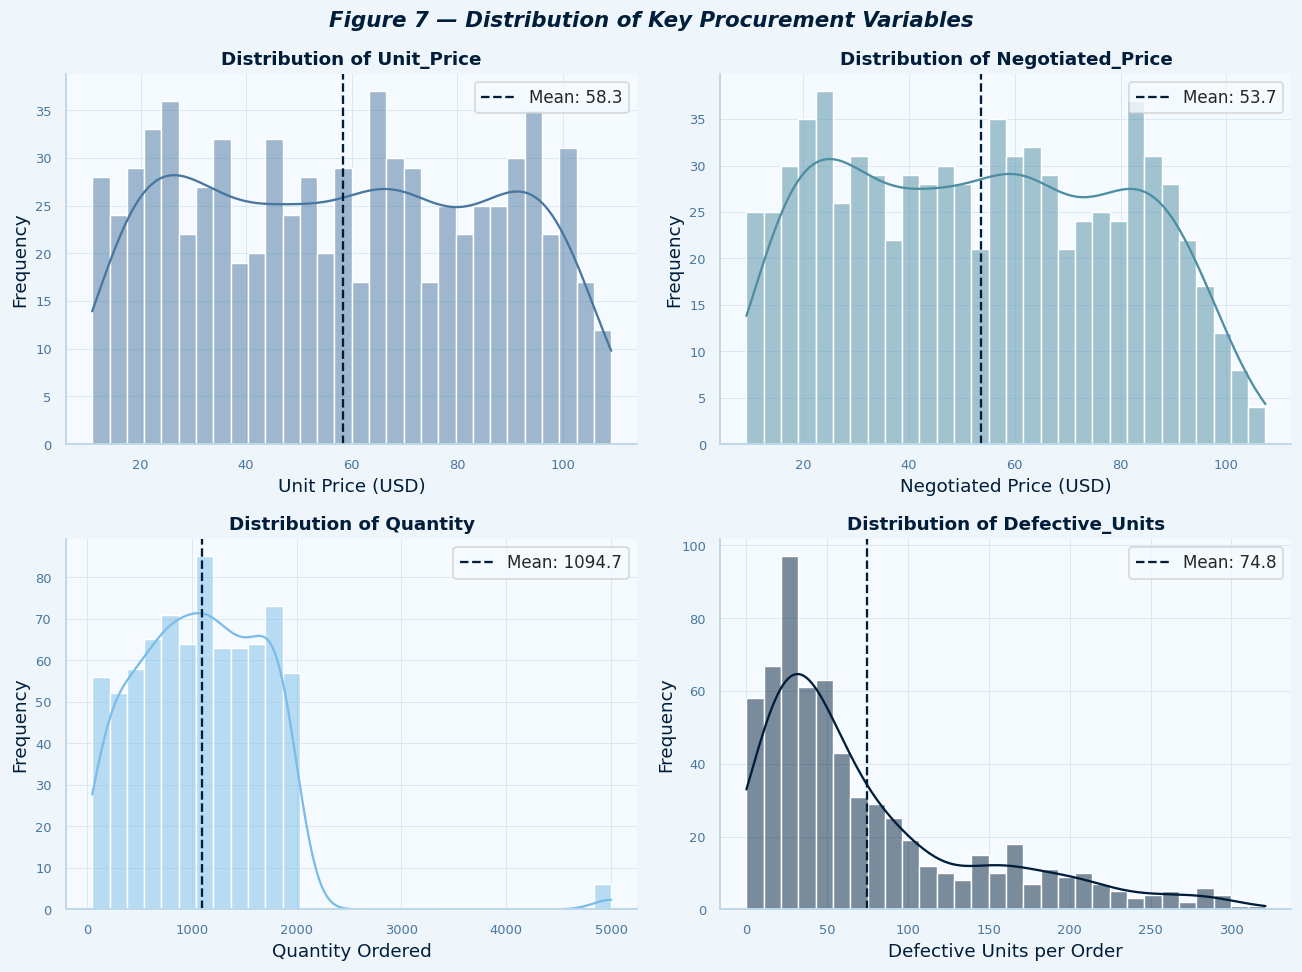

In [154]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

plots = [
    ('Unit_Price',       BLUE['mid'],  'Unit Price (USD)'),
    ('Negotiated_Price', BLUE['teal'], 'Negotiated Price (USD)'),
    ('Quantity',         BLUE['sky'],  'Quantity Ordered'),
    ('Defective_Units',  BLUE['navy'], 'Defective Units per Order'),
]

for ax, (col, color, xlabel) in zip(axes, plots):
    data = df[col].dropna()

    sns.histplot(
        data,
        bins=30,
        kde=True,
        color=color,
        ax=ax
    )

    # Mean line
    ax.axvline(
        data.mean(),
        color=BLUE['navy'],
        linestyle='--',
        linewidth=1.5,
        label=f"Mean: {data.mean():.1f}"
    )

    # Titles & labels
    ax.set_title(
        f'Distribution of {col}',
        fontsize=12,
        fontweight='bold',
        color=BLUE['navy']
    )

    ax.set_xlabel(xlabel, color=BLUE['navy'])
    ax.set_ylabel('Frequency', color=BLUE['navy'])

    # Apply styling
    clean_ax(ax)

    ax.legend()

plt.suptitle(
    'Figure 7 — Distribution of Key Procurement Variables',
    fontsize=14,
    fontweight='bold',
    fontstyle='italic',
    color=BLUE['navy']
)

plt.tight_layout()
plt.show()

Figure 7 shows that both Unit Price and Negotiated Price show a relatively uniform spread across orders, though successful procurement negotiations are evident as the average cost shifts downward from a Unit Price mean of 58.3 USD to a Negotiated Price mean of 53.7 USD. The Quantity Ordered chart reveals that the vast majority of orders are consistently clustered between 0 and 2,000 units, resulting in a mean of 1,094.7 units despite a few isolated bulk orders near 5,000. Finally, the Defective Units per Order distribution is heavily skewed to the right; while most orders have very low defect counts (under 50), a long tail of infrequent, high-defect orders pulls the overall mean up to 74.8 defective units.

### **Compliance vs. Numerical Features**

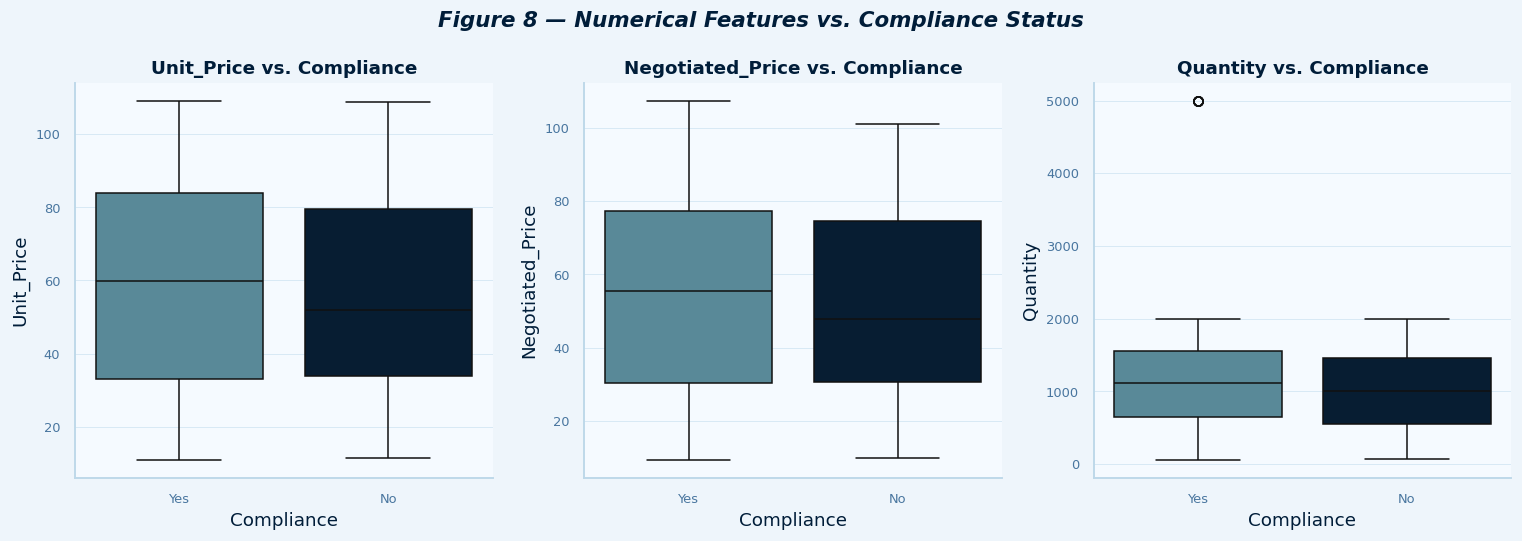

In [155]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

box_features = ['Unit_Price', 'Negotiated_Price', 'Quantity']

# Blue Ocean compliance colors
box_colors = {
    'Yes': BLUE['teal'],
    'No': BLUE['navy']
}

for ax, col in zip(axes, box_features):

    sns.boxplot(
        data=df,
        x='Compliance',
        y=col,
        palette=box_colors,
        ax=ax
    )

    ax.set_title(
        f'{col} vs. Compliance',
        fontsize=12,
        fontweight='bold',
        color=BLUE['navy']
    )

    ax.set_xlabel('Compliance', color=BLUE['navy'])
    ax.set_ylabel(col, color=BLUE['navy'])

    # Apply Blue Ocean styling
    clean_ax(ax)

plt.suptitle(
    'Figure 8 — Numerical Features vs. Compliance Status',
    fontsize=14,
    fontweight='bold',
    fontstyle='italic',
    color=BLUE['navy']
)

plt.tight_layout()
plt.show()

Figure 8 compares three numerical procurement variables—Unit Price, Negotiated Price, and Quantity—against whether an order was compliant (Yes, in green) or non-compliant (No, in red). Across all three box plots, the data reveals that compliant orders generally feature slightly higher median values for unit prices, negotiated prices, and order quantities compared to non-compliant ones. Additionally, the overall distribution spreads, ranges, and quartiles remain remarkably similar between the two groups, with the only notable anomaly being a single high-volume outlier of 5,000 units that managed to achieve full compliance.

## **Data Visualization**

### **Correlation Heatmap**

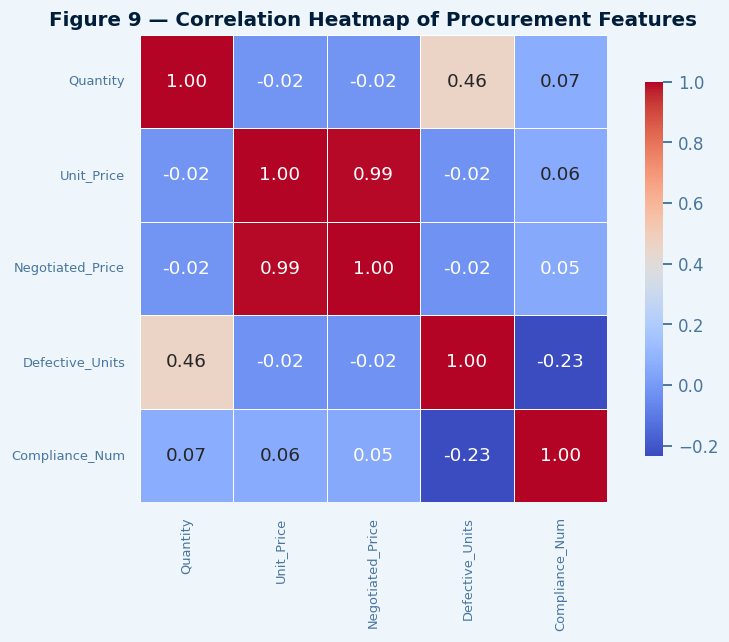

In [158]:
df_corr = df[['Quantity', 'Unit_Price', 'Negotiated_Price', 'Defective_Units']].copy()
df_corr['Compliance_Num'] = (df['Compliance'] == 'Yes').astype(int)

corr_matrix = df_corr.corr()

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

# Title styling (Blue Ocean)
ax.set_title(
    'Figure 9 — Correlation Heatmap of Procurement Features',
    fontsize=13,
    fontweight='bold',
    color=BLUE['navy']
)

# Apply consistent styling
clean_ax(ax, grid_axis=None)

plt.tight_layout()
plt.show()

This correlation heatmap illustrates the relationships between five key procurement metrics, with values ranging from -1.00 (perfect negative correlation) to 1.00 (perfect positive correlation). The most prominent finding is a nearly perfect positive relationship of 0.99 between Unit_Price and Negotiated_Price, confirming that negotiated prices scale almost directly with the baseline unit price. There is also a moderate positive correlation of 0.46 between Quantity and Defective_Units, suggesting that larger order volumes naturally tend to yield higher numbers of defects. Conversely, Compliance_Num exhibits a notable negative correlation of -0.23 with Defective_Units, establishing that orders with higher defect counts are significantly less likely to be compliant. All other variable pairings show near-zero values (ranging from -0.02 to 0.07), indicating virtually no linear relationship between them.

# **III. DATA PREPARATION**

## **Feature Engineering**


**STEP 1: PARSE DATES & COMPUTE LEAD TIME**

In [108]:
df_eng = df.copy()

df_eng['Order_Date']    = pd.to_datetime(df_eng['Order_Date'])
df_eng['Delivery_Date'] = pd.to_datetime(df_eng['Delivery_Date'])

df_eng['lead_time_days'] = (df_eng['Delivery_Date'] - df_eng['Order_Date']).dt.days

# Impute missing lead time with -1 (no delivery = non-delivery event)
df_eng['lead_time_days'] = df_eng['lead_time_days'].fillna(-1)

print("Lead time feature created.")
print(df_eng['lead_time_days'].describe().round(2))

Lead time feature created.
count    777.00
mean       9.46
std        6.55
min       -5.00
25%        4.00
50%       10.00
75%       15.00
max       20.00
Name: lead_time_days, dtype: float64


Lead time (days from order to delivery) is the primary numerical signal for Prediction 1 — Delay Risk. Orders with unusually high lead times are statistically more likely to breach delivery commitments. Orders with no delivery date (Cancelled or Pending) are assigned -1 to distinguish them from completed deliveries — this negative sentinel value also signals Predictions 1 and 2 directly through

**Step 2: Compute Derived KPI Features**

In [109]:
df_eng['Defective_Units'] = df_eng['Defective_Units'].fillna(0)

df_eng['savings_rate'] = ((df_eng['Unit_Price'] - df_eng['Negotiated_Price'])
                           / df_eng['Unit_Price']) * 100

df_eng['defect_rate']  = (df_eng['Defective_Units'] / df_eng['Quantity']) * 100

df_eng['order_value']  = df_eng['Quantity'] * df_eng['Negotiated_Price']

print("Derived features created: savings_rate, defect_rate, order_value")
print(df_eng[['savings_rate', 'defect_rate', 'order_value']].describe().round(3))

Derived features created: savings_rate, defect_rate, order_value
       savings_rate  defect_rate  order_value
count       777.000      777.000      777.000
mean          7.968        5.780    58396.006
std           4.139        5.270    48236.432
min           1.005        0.000      772.800
25%           4.280        2.000    22221.850
50%           7.900        3.751    46776.360
75%          11.528        9.803    83088.710
max          14.993       35.714   432900.000


This statistical summary outlines three newly derived KPIs calculated across 777 procurement orders to measure negotiation success, quality control, and financial risk. The savings_rate averages 7.97% and spans up to 14.99%, serving as a vital metric since low savings indicate poor negotiation leverage and a higher risk of supplier non-compliance. Quality performance is captured by the defect_rate, which averages 5.78% per order; however, a severe quality compliance failure is evident at the maximum end, where defects spike to 35.71%. Finally, the order_value represents the total monetary scale of procurement, averaging $58,396 but varying wildly from a minor $772.80 purchase to a massive $432,900 contract. These high-value orders are critical focal points because they attract the greatest internal scrutiny and carry the heaviest financial consequences in the event of delays or cancellations.

**Step 3: Encode Categorical Features**

In [110]:
le = LabelEncoder()

df_eng['Supplier_enc']    = le.fit_transform(df_eng['Supplier'])
df_eng['Category_enc']    = le.fit_transform(df_eng['Item_Category'])
df_eng['OrderStatus_enc'] = le.fit_transform(df_eng['Order_Status'])

# Encode target variable
df_eng['target'] = (df_eng['Compliance'] == 'Yes').astype(int)

print("Encoding complete.")
print("\nTarget distribution (1 = Compliant, 0 = Non-Compliant):")
print(df_eng['target'].value_counts())

Encoding complete.

Target distribution (1 = Compliant, 0 = Non-Compliant):
target
1    640
0    137
Name: count, dtype: int64


The target variable distribution reveals a clear class imbalance, consisting of 640 compliant orders (1) and 137 non-compliant orders (0) out of the 777 total records. By applying label encoding to categorical columns like Order_Status, the model can mathematically process different states—such as mapping Pending and Cancelled statuses to their strong statistical association with non-compliance. Ultimately, instead of a simple yes-or-no guess, the trained model will output a continuous probability score for non-compliance, which serves as the foundational risk score driving all automated predictions in the deployment phase.

**Step 4: Feature Selection and Train-Test Split**

In [111]:
feature_cols = [
    'lead_time_days',
    'savings_rate',
    'defect_rate',
    'order_value',
    'Quantity',
    'Supplier_enc',
    'Category_enc',
    'OrderStatus_enc'
]

X = df_eng[feature_cols].copy()
y = df_eng['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Training set:  {X_train.shape[0]} samples")
print(f"Test set:      {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())

Training set:  621 samples
Test set:      156 samples

Class distribution in training set:
target
1    512
0    109
Name: count, dtype: int64


**Step 5: Handle Class Imbalance with SMOTE**

Before SMOTE — {1: 512, 0: 109}
After  SMOTE — {1: 512, 0: 512}


Text(0.5, 0.98, 'Figure 10 — Class Distribution Before and After SMOTE')

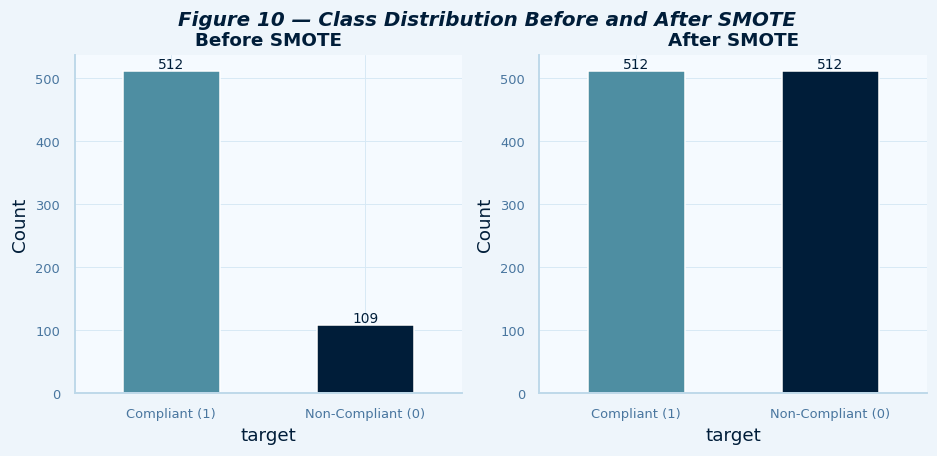

In [159]:
# SMOTE — BALANCING CLASS DISTRIBUTION

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE — {y_train.value_counts().to_dict()}")
print(f"After  SMOTE — {pd.Series(y_train_sm).value_counts().to_dict()}")

# VISUALIZATION — BEFORE vs AFTER SMOTE

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE

y_train.value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=[BLUE['teal'], BLUE['navy']],
    edgecolor='white'
)

axes[0].set_title(
    'Before SMOTE',
    fontsize=12,
    fontweight='bold',
    color=BLUE['navy']
)

axes[0].set_xticklabels(
    ['Compliant (1)', 'Non-Compliant (0)'],
    rotation=0
)

axes[0].set_ylabel('Count', color=BLUE['navy'])
clean_ax(axes[0], grid_axis='y')

for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(int(bar.get_height())),
        ha='center',
        fontsize=9,
        color=BLUE['navy']
    )


# After SMOTE

pd.Series(y_train_sm).value_counts().plot(
    kind='bar',
    ax=axes[1],
    color=[BLUE['teal'], BLUE['navy']],
    edgecolor='white'
)

axes[1].set_title(
    'After SMOTE',
    fontsize=12,
    fontweight='bold',
    color=BLUE['navy']
)

axes[1].set_xticklabels(
    ['Compliant (1)', 'Non-Compliant (0)'],
    rotation=0
)

axes[1].set_ylabel('Count', color=BLUE['navy'])
clean_ax(axes[1], grid_axis='y')

for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(int(bar.get_height())),
        ha='center',
        fontsize=9,
        color=BLUE['navy']
    )


# MAIN TITLE

plt.suptitle(
    'Figure 10 — Class Distribution Before and After SMOTE',
    fontsize=13,
    fontweight='bold',
    fontstyle='italic',
    color=BLUE['navy']
)

The Before SMOTE chart on the left highlights a major discrepancy, where Compliant orders (green) heavily outnumber the minority Non-Compliant orders (red). The After SMOTE chart on the right demonstrates how the technique successfully balances the dataset by synthetically generating new, artificial examples of Non-Compliant orders until both categories achieve an equal count of just over 500 instances..

**Step 6: Feature Scaling**

In [113]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling complete.")
print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled test set shape:     {X_test_scaled.shape}")

Feature scaling complete.
Scaled training set shape: (1024, 8)
Scaled test set shape:     (156, 8)


**Data Visualization**

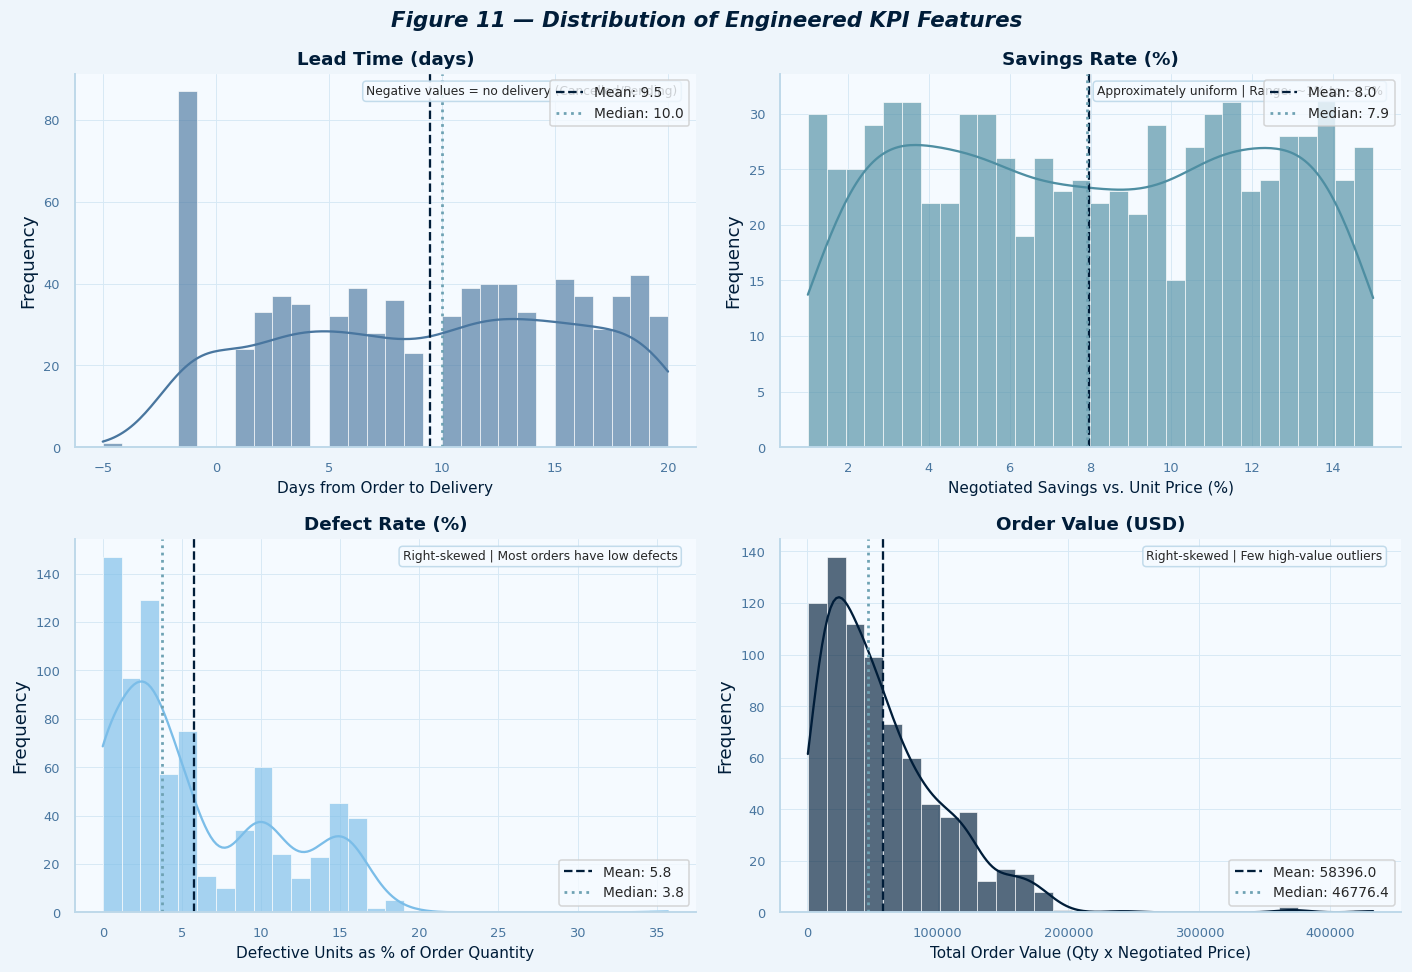

In [160]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

dist_config = [
    ('lead_time_days', BLUE['mid'],  'Lead Time (days)',
     'Days from Order to Delivery',
     'Negative values = no delivery (Cancelled/Pending)'),

    ('savings_rate',   BLUE['teal'], 'Savings Rate (%)',
     'Negotiated Savings vs. Unit Price (%)',
     'Approximately uniform | Range: ~1% to ~15%'),

    ('defect_rate',    BLUE['sky'],  'Defect Rate (%)',
     'Defective Units as % of Order Quantity',
     'Right-skewed | Most orders have low defects'),

    ('order_value',    BLUE['navy'], 'Order Value (USD)',
     'Total Order Value (Qty x Negotiated Price)',
     'Right-skewed | Few high-value outliers'),
]

for ax, (col, color, title, xlabel, note) in zip(axes, dist_config):
    mean_val = df_eng[col].mean()
    median_val = df_eng[col].median()

    sns.histplot(
        df_eng[col],
        bins=30,
        kde=True,
        color=color,
        ax=ax,
        alpha=0.65,
        edgecolor='white',
        linewidth=0.4
    )

    # Mean line
    ax.axvline(
        mean_val,
        color=BLUE['navy'],
        linestyle='--',
        linewidth=1.5,
        label=f'Mean: {mean_val:.1f}'
    )

    # Median line
    ax.axvline(
        median_val,
        color=BLUE['slate'],
        linestyle=':',
        linewidth=1.8,
        label=f'Median: {median_val:.1f}'
    )

    ax.set_title(
        title,
        fontsize=12,
        fontweight='bold',
        color=BLUE['navy']
    )

    ax.set_xlabel(xlabel, fontsize=10, color=BLUE['navy'])
    ax.set_ylabel('Frequency', color=BLUE['navy'])

    # Apply Blue Ocean styling
    clean_ax(ax)

    ax.legend(fontsize=9)

    ax.text(
        0.97, 0.97,
        note,
        transform=ax.transAxes,
        fontsize=8,
        va='top',
        ha='right',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor=BLUE['white'],
            edgecolor=BLUE['ice'],
            alpha=0.9
        )
    )

plt.suptitle(
    'Figure 11 — Distribution of Engineered KPI Features',
    fontsize=14,
    fontweight='bold',
    fontstyle='italic',
    color=BLUE['navy']
)

plt.tight_layout()
plt.show()

Figure 11 displays the frequency distributions for four engineered procurement KPIs, detailing their means (dashed lines) and medians (dotted lines). Lead Time shows a wide distribution averaging 9.5 days, marked by a prominent spike of negative values representing unfulfilled or cancelled orders. Savings Rate exhibits an approximately uniform, even spread across orders, averaging 8.0% within a 1% to 15% range. Both Defect Rate and Order Value are heavily right-skewed; most orders cluster around lower values—yielding a median defect rate of 3.8% and a median order value of 46,776.40 but infrequent, high-impact outliers pull their respective averages up to a 5.8% defect rate and a $58,396.00 order value.

# **IV. MODELING**


## **Logistic Regression**

Logistic Regression serves as the interpretable baseline. Its coefficients directly reveal which features push orders toward non-compliance. For example, a high defect_rate coefficient confirms that quality failures drive non-compliance, while a strong OrderStatus_enc coefficient shows that order status (Pending/Cancelled) is predictive of compliance failures. These coefficient insights set the analytical context for the three deployment predictions.

**Step 1: Baseline Training**

In [115]:
lr_base = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                              class_weight='balanced')
lr_base.fit(X_train_scaled, y_train_sm)

y_pred_lr = lr_base.predict(X_test_scaled)
y_prob_lr = lr_base.predict_proba(X_test_scaled)[:, 1]

acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)

print("LOGISTIC REGRESSION — Baseline Results")
print(f"  Accuracy:  {acc_lr:.4f}")
print(f"  Precision: {prec_lr:.4f}")
print(f"  Recall:    {rec_lr:.4f}")
print(f"  F1 Score:  {f1_lr:.4f}")
print(f"  ROC-AUC:   {auc_lr:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_lr,
                             target_names=['Non-Compliant', 'Compliant']))

LOGISTIC REGRESSION — Baseline Results
  Accuracy:  0.5385
  Precision: 0.8415
  Recall:    0.5391
  F1 Score:  0.6571
  ROC-AUC:   0.5826

Detailed Classification Report:
               precision    recall  f1-score   support

Non-Compliant       0.20      0.54      0.29        28
    Compliant       0.84      0.54      0.66       128

     accuracy                           0.54       156
    macro avg       0.52      0.54      0.48       156
 weighted avg       0.73      0.54      0.59       156



Logistic Regression model demonstrates poor overall performance, yielding a low accuracy of 53.85% and an ROC-AUC of 0.5826, which is only slightly better than a random guess. While the model achieves a high precision of 84.15% for the compliant class, this is heavily skewed by the underlying data imbalance (128 compliant vs. 28 non-compliant orders). In contrast, its ability to correctly identify actual problems is weak, capturing only 54% of both compliant and non-compliant cases (53.91% overall recall). This leaves the model with a dismal 0.29 F1-score for the critical non-compliant class, proving that this baseline configuration is currently unreliable for flagging high-risk procurement orders.

**Step 2: Hyperparameter Tuning (GridSearchCV)**

In [116]:
lr_param_grid = {
    'C':       [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear']
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                       class_weight='balanced'),
    param_grid=lr_param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

lr_grid.fit(X_train_scaled, y_train_sm)

print(f"Best Parameters:  {lr_grid.best_params_}")
print(f"Best CV F1 Score: {lr_grid.best_score_:.4f}")

Best Parameters:  {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1 Score: 0.6269


**Step 3: Final Logistic Regression Model**

LOGISTIC REGRESSION — Tuned Final Model
  Accuracy:  0.5449
  Precision: 0.8434
  Recall:    0.5469
  F1 Score:  0.6635
  ROC-AUC:   0.5837


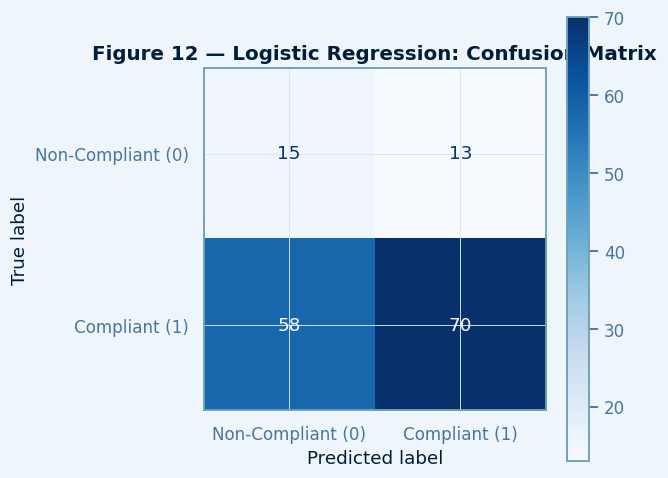

In [161]:
lr_best = lr_grid.best_estimator_

y_pred_lr_best = lr_best.predict(X_test_scaled)
y_prob_lr_best = lr_best.predict_proba(X_test_scaled)[:, 1]

acc_lr_best  = accuracy_score(y_test, y_pred_lr_best)
prec_lr_best = precision_score(y_test, y_pred_lr_best)
rec_lr_best  = recall_score(y_test, y_pred_lr_best)
f1_lr_best   = f1_score(y_test, y_pred_lr_best)
auc_lr_best  = roc_auc_score(y_test, y_prob_lr_best)

print("LOGISTIC REGRESSION — Tuned Final Model")
print(f"  Accuracy:  {acc_lr_best:.4f}")
print(f"  Precision: {prec_lr_best:.4f}")
print(f"  Recall:    {rec_lr_best:.4f}")
print(f"  F1 Score:  {f1_lr_best:.4f}")
print(f"  ROC-AUC:   {auc_lr_best:.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr_best,
    display_labels=['Non-Compliant (0)', 'Compliant (1)'],
    colorbar=True, ax=ax, cmap='Blues'
)
ax.set_title('Figure 12 — Logistic Regression: Confusion Matrix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



This visualizes the baseline Logistic Regression model's predictions against the actual outcomes for 156 procurement orders. The model successfully identified 70 True Positives (correctly predicted compliant orders) and 15 True Negatives (correctly predicted non-compliant orders). However, it exhibits a high error rate, generating 13 False Negatives (missing nearly half of the actual non-compliant orders by labeling them compliant) and a substantial 58 False Positives (mistakenly flagging compliant orders as non-compliant). This high volume of misclassifications confirms the model's weak predictive accuracy and highlights a tendency to generate excessive false alarms while missing critical compliance risks.

## **Coefficient Plot (Feature Importance)**

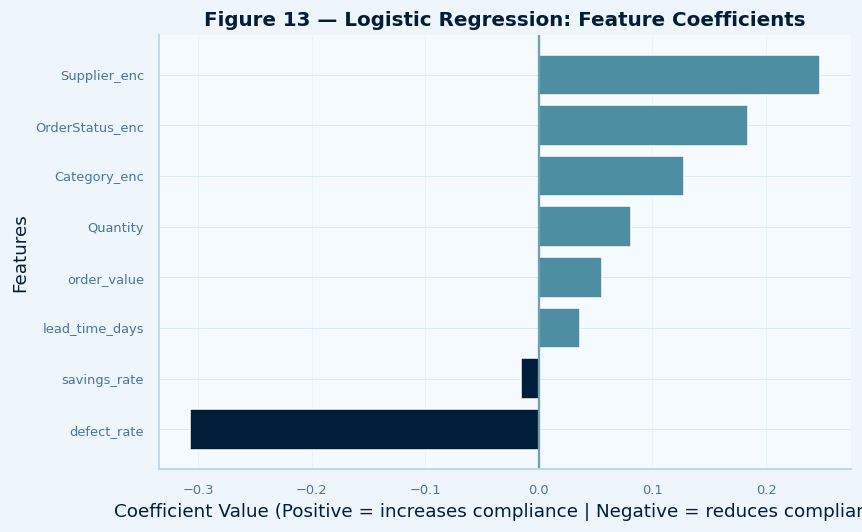

In [162]:
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_best.coef_[0]
}).sort_values('Coefficient')

# Blue Ocean diverging colors
colors_coef = [
    BLUE['teal'] if c > 0 else BLUE['navy']
    for c in coef_df['Coefficient']
]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    coef_df['Feature'],
    coef_df['Coefficient'],
    color=colors_coef,
    edgecolor='white'
)

# Zero reference line
ax.axvline(
    x=0,
    color=BLUE['slate'],
    linewidth=1.5
)

# Titles & labels
ax.set_title(
    'Figure 13 — Logistic Regression: Feature Coefficients',
    fontsize=13,
    fontweight='bold',
    color=BLUE['navy']
)

ax.set_xlabel(
    'Coefficient Value (Positive = increases compliance | Negative = reduces compliance)',
    color=BLUE['navy']
)

ax.set_ylabel('Features', color=BLUE['navy'])

# Apply Blue Ocean styling
clean_ax(ax, grid_axis='x')

ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

This figure shows the model's strongest negative predictor is defect_rate (around -0.31), meaning that as the defect rate increases, the likelihood of compliance significantly drops, followed by a very minor negative impact from savings_rate. Conversely, the strongest positive drivers increasing predicted compliance are the encoded categorical variables, led by Supplier_enc (roughly +0.25), OrderStatus_enc, and Category_enc. Continuous variables like Quantity, order_value, and lead_time_days show mild positive impacts, suggesting that larger, higher-value orders with slightly longer lead times are marginally more likely to be classified as compliant by this model.

## **Decision Tree Classifier**

This model is ideal because it translates machine learning predictions into direct, logical business actions—such as automatically flagging a "Pending" order with a lead time exceeding 45 days as a non-compliant delay risk. By mapping out clear, step-by-step logic gates, these rules can be easily extracted and handed to frontline procurement staff as a manual screening checklist. This ensures the team can seamlessly audit orders and mitigate risk on the ground, providing operational resilience even when automated software scoring tools are unavailable.

**Step 1: Baseline Training**

In [119]:
dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE,
                                  class_weight='balanced')
dt_base.fit(X_train_scaled, y_train_sm)

y_pred_dt = dt_base.predict(X_test_scaled)
y_prob_dt = dt_base.predict_proba(X_test_scaled)[:, 1]

acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt  = recall_score(y_test, y_pred_dt)
f1_dt   = f1_score(y_test, y_pred_dt)
auc_dt  = roc_auc_score(y_test, y_prob_dt)

print("DECISION TREE — Baseline Results")
print(f"  Accuracy:  {acc_dt:.4f}")
print(f"  Precision: {prec_dt:.4f}")
print(f"  Recall:    {rec_dt:.4f}")
print(f"  F1 Score:  {f1_dt:.4f}")
print(f"  ROC-AUC:   {auc_dt:.4f}")
print(f"  Tree Depth (unpruned): {dt_base.get_depth()}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_dt,
                             target_names=['Non-Compliant', 'Compliant']))

DECISION TREE — Baseline Results
  Accuracy:  0.7308
  Precision: 0.8839
  Recall:    0.7734
  F1 Score:  0.8250
  ROC-AUC:   0.6546
  Tree Depth (unpruned): 26

Detailed Classification Report:
               precision    recall  f1-score   support

Non-Compliant       0.34      0.54      0.42        28
    Compliant       0.88      0.77      0.82       128

     accuracy                           0.73       156
    macro avg       0.61      0.65      0.62       156
 weighted avg       0.79      0.73      0.75       156



The baseline Decision Tree model demonstrates a solid improvement over logistic regression, achieving a higher overall accuracy of 73.08% and a strong precision of 88.39% for compliant orders. It successfully captures 77.34% of compliant cases (recall), though its ability to catch the critical non-compliant orders stands lower at 54%, resulting in a modest 0.42 F1-score for that specific minority class. With an ROC-AUC of 0.6546, the model shows decent discriminative power, but its massive, unpruned Tree Depth of 26 indicates it is highly complex. While this depth allows it to create explicit, detailed logical paths, it also suggests a strong risk of overfitting to the training data, meaning the tree will need pruning to maintain reliable performance on new procurement data.

**Step 2: Hyperparameter Tuning (GridSearchCV)**

In [120]:
dt_param_grid = {
    'max_depth':         [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 4, 8],
    'criterion':         ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    param_grid=dt_param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

dt_grid.fit(X_train_scaled, y_train_sm)

print(f"Best Parameters:  {dt_grid.best_params_}")
print(f"Best CV F1 Score: {dt_grid.best_score_:.4f}")

Best Parameters:  {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV F1 Score: 0.8055


**Step 3: Final Decision Tree Model**

DECISION TREE — Tuned Final Model
  Accuracy:  0.6603
  Precision: 0.8505
  Recall:    0.7109
  F1 Score:  0.7745
  ROC-AUC:   0.5723
  Final Tree Depth: 24

Detailed Classification Report:
               precision    recall  f1-score   support

Non-Compliant       0.24      0.43      0.31        28
    Compliant       0.85      0.71      0.77       128

     accuracy                           0.66       156
    macro avg       0.55      0.57      0.54       156
 weighted avg       0.74      0.66      0.69       156



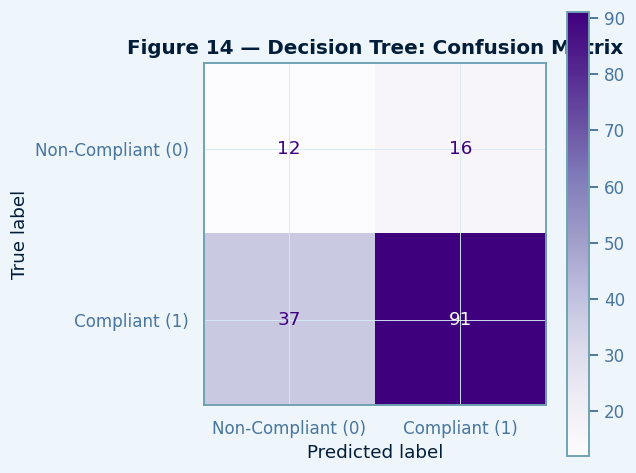

In [163]:
dt_best = dt_grid.best_estimator_

y_pred_dt_best = dt_best.predict(X_test_scaled)
y_prob_dt_best = dt_best.predict_proba(X_test_scaled)[:, 1]

acc_dt_best  = accuracy_score(y_test, y_pred_dt_best)
prec_dt_best = precision_score(y_test, y_pred_dt_best)
rec_dt_best  = recall_score(y_test, y_pred_dt_best)
f1_dt_best   = f1_score(y_test, y_pred_dt_best)
auc_dt_best  = roc_auc_score(y_test, y_prob_dt_best)

print("DECISION TREE — Tuned Final Model")
print(f"  Accuracy:  {acc_dt_best:.4f}")
print(f"  Precision: {prec_dt_best:.4f}")
print(f"  Recall:    {rec_dt_best:.4f}")
print(f"  F1 Score:  {f1_dt_best:.4f}")
print(f"  ROC-AUC:   {auc_dt_best:.4f}")
print(f"  Final Tree Depth: {dt_best.get_depth()}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_dt_best,
                             target_names=['Non-Compliant', 'Compliant']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt_best,
    display_labels=['Non-Compliant (0)', 'Compliant (1)'],
    colorbar=True, ax=ax, cmap='Purples'
)
ax.set_title('Figure 14 — Decision Tree: Confusion Matrix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

This figure shows the performance of the tuned final Decision Tree model across 156 procurement orders. After pruning the model to a final tree depth of 24, it achieved a moderate overall accuracy of 66.03% and successfully identified 91 True Positives (correctly predicted compliant orders) along with 12 True Negatives (correctly predicted non-compliant orders). Despite maintaining a high precision of 85.05% for compliant orders, the model's ability to isolate risks remains restricted, yielding a low 0.31 F1-score for the non-compliant class due to 16 False Negatives (missing over half of the actual non-compliant orders) and 37 False Positives (falsely flagging compliant orders). With an ROC-AUC of 0.5723, the tuning process slightly traded off baseline predictive power for better generalization, meaning it reduces overfitting but still struggles to sharply distinguish between compliant and non-compliant transactions.

## **Decision Tree Visualization (Pruned)**

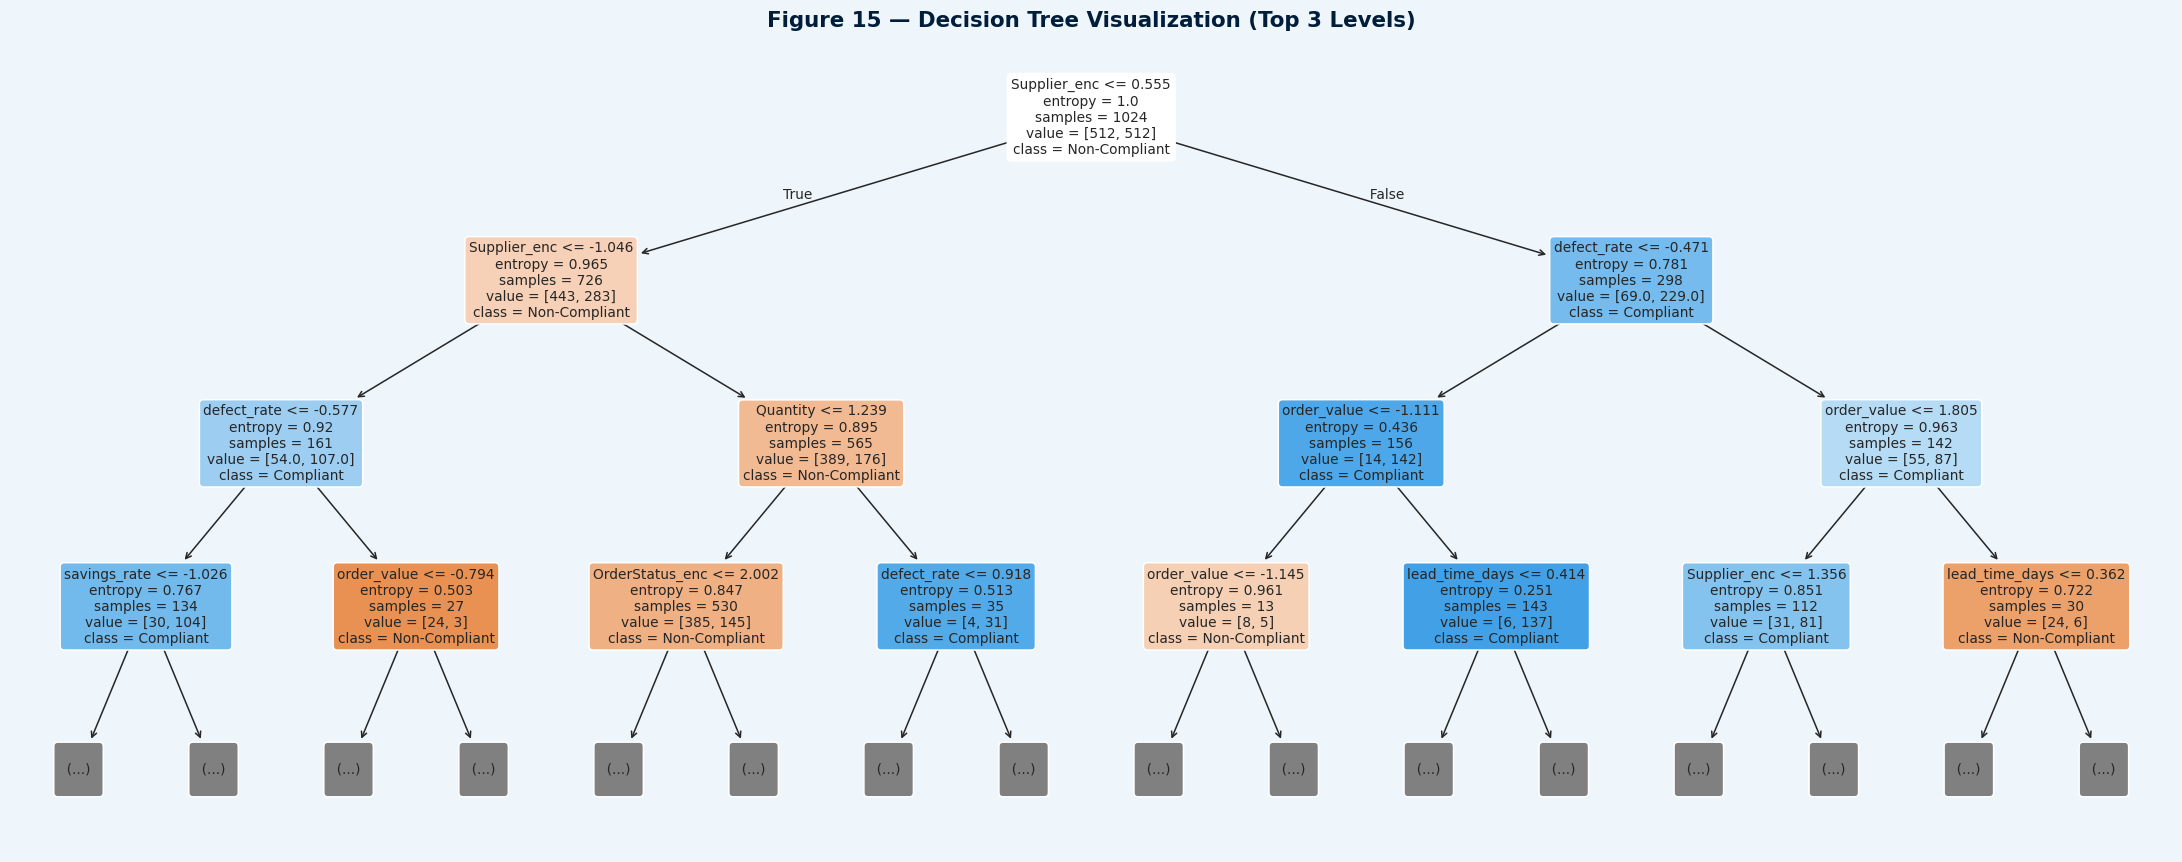

TOP DECISION RULES (first 3 levels):
|--- Supplier_enc <= 0.56
|   |--- Supplier_enc <= -1.05
|   |   |--- defect_rate <= -0.58
|   |   |   |--- savings_rate <= -1.03
|   |   |   |   |--- class: 1
|   |   |   |--- savings_rate >  -1.03
|   |   |   |   |--- truncated branch of depth 8
|   |   |--- defect_rate >  -0.58
|   |   |   |--- order_value <= -0.79
|   |   |   |   |--- class: 1
|   |   |   |--- order_value >  -0.79
|   |   |   |   |--- truncated branch of depth 3
|   |--- Supplier_enc >  -1.05
|   |   |--- Quantity <= 1.24
|   |   |   |--- OrderStatus_enc <= 2.00
|   |   |   |   |--- truncated branch of depth 21
|   |   |   |--- OrderStatus_enc >  2.00
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- Quantity >  1.24
|   |   |   |--- defect_rate <= 0.92
|   |   |   |   |--- class: 1
|   |   |   |--- defect_rate >  0.92
|   |   |   |   |--- truncated branch of depth 3
|--- Supplier_enc >  0.56
|   |--- defect_rate <= -0.47
|   |   |--- order_value <= -1.11
|   |   |  

In [164]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_best,
    max_depth=3,
    feature_names=feature_cols,
    class_names=['Non-Compliant', 'Compliant'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Figure 15 — Decision Tree Visualization (Top 3 Levels)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top decision rules as text for reference
print("TOP DECISION RULES (first 3 levels):")
print(export_text(dt_best, feature_names=feature_cols, max_depth=3))


This figure visualizes the top three levels of the final Decision Tree model, illustrating the explicit step-by-step logic gates used to classify procurement risk. The root node splits the entire dataset based on Supplier_enc, separating specific vendors into a higher-risk branch on the left (orange nodes, defaulting toward Non-Compliant) and a lower-risk branch on the right (blue nodes, defaulting toward Compliant). As the tree branches downward, it continuously refines its predictions by evaluating critical KPI thresholds such as defect_rate, Quantity, and order_value. This hierarchical flow maps out exactly how the model processes data to determine order outcomes, providing a clear visual representation of the transparent rules that procurement staff can use to audit risk.

## **Feature Importance Plot**

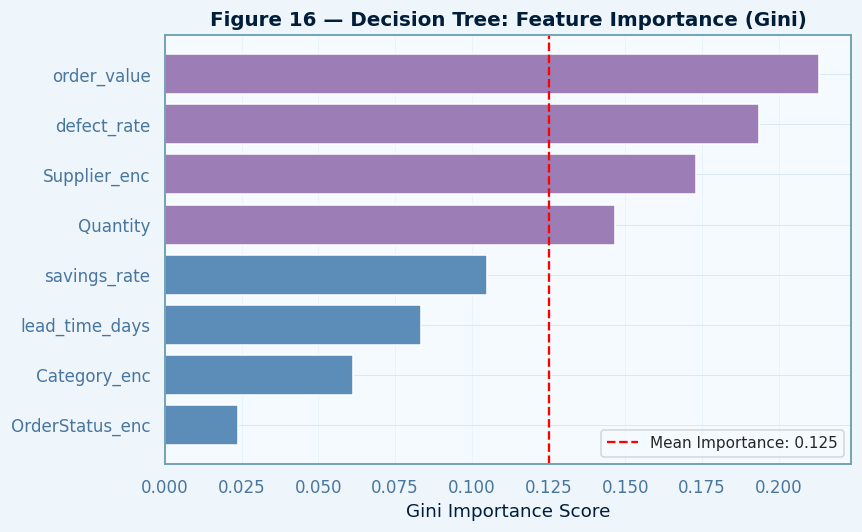

In [165]:
dt_importances = dt_best.feature_importances_
dt_imp_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': dt_importances
}).sort_values('Importance', ascending=True)

colors_dt_imp = ['#9C7DB5' if imp >= dt_importances.mean() else '#5B8DB8'
                 for imp in dt_imp_df['Importance']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(dt_imp_df['Feature'], dt_imp_df['Importance'],
        color=colors_dt_imp, edgecolor='white')
ax.axvline(x=dt_importances.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean Importance: {dt_importances.mean():.3f}')
ax.set_title('Figure 16 — Decision Tree: Feature Importance (Gini)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Gini Importance Score')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

This illustrates the relative importance of each feature in the Decision Tree model based on its Gini Importance Score, with the red dashed line representing the mean importance threshold of 0.125. Four key features score above this average (highlighted in purple), establishing them as the primary drivers of the model's split logic: order_value leads as the most influential predictor, followed closely by defect_rate, Supplier_enc, and Quantity. Conversely, the remaining four features—savings_rate, lead_time_days, Category_enc, and OrderStatus_enc—fall below the mean threshold (shown in blue), indicating they play a much smaller, supporting role in how the tree ultimately determines procurement compliance risk.

## **Random Forest Classifier**

Random Forest is the primary candidate for deployment. By aggregating hundreds of decision trees, it produces stable, high-accuracy compliance risk scores that are robust to noise and outliers. Its feature importance rankings confirm which variables matter most across the three predictions like lead_time_days for delays, OrderStatus_enc for cancellations, and Supplier_enc/defect_rate for supplier non-compliance.

**Step 1: Baseline Training**

In [124]:
rf_base = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE,
                                  class_weight='balanced')
rf_base.fit(X_train_sm, y_train_sm)

y_pred_rf = rf_base.predict(X_test_scaled)
y_prob_rf = rf_base.predict_proba(X_test_scaled)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_prob_rf)

print("RANDOM FOREST — Baseline Results")
print(f"  Accuracy:  {acc_rf:.4f}")
print(f"  Precision: {prec_rf:.4f}")
print(f"  Recall:    {rec_rf:.4f}")
print(f"  F1 Score:  {f1_rf:.4f}")
print(f"  ROC-AUC:   {auc_rf:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf,
                             target_names=['Non-Compliant', 'Compliant']))

RANDOM FOREST — Baseline Results
  Accuracy:  0.8205
  Precision: 0.8205
  Recall:    1.0000
  F1 Score:  0.9014
  ROC-AUC:   0.3329

Detailed Classification Report:
               precision    recall  f1-score   support

Non-Compliant       0.00      0.00      0.00        28
    Compliant       0.82      1.00      0.90       128

     accuracy                           0.82       156
    macro avg       0.41      0.50      0.45       156
 weighted avg       0.67      0.82      0.74       156



Random Forest model presents a strong set of results driven entirely by the dataset's class imbalance. While it achieves a seemingly high accuracy of 82.05% and a perfect 1.00 recall for compliant orders, the model is actually non-functional for risk detection; it has completely defaulted to predicting "Compliant" for every single transaction. This is exposed by the 0.00 recall and F1-score for Non-Compliant orders, meaning it failed to catch a single one of the 28 actual risks. This total blind spot results in an ROC-AUC of 0.3329, which performs significantly worse than a random guess ($0.50$). This indicates that the un-tuned ensemble has simply memorized the majority class and must be adjusted with class weights or hyperparameter tuning to become operationally useful.

**Step 2: Hyperparameter Tuning (GridSearchCV)**

In [125]:
rf_param_grid = {
    'n_estimators': [20, 50],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    param_grid=rf_param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

rf_grid.fit(X_train_sm, y_train_sm)

print(f"Best Parameters:  {rf_grid.best_params_}")
print(f"Best CV F1 Score: {rf_grid.best_score_:.4f}")

Best Parameters:  {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 50}
Best CV F1 Score: 0.8420


**Step 3: Final Random Forest Model**

RANDOM FOREST — Tuned Final Model
  Accuracy:  0.8205
  Precision: 0.8205
  Recall:    1.0000
  F1 Score:  0.9014
  ROC-AUC:   0.3571

Detailed Classification Report:
               precision    recall  f1-score   support

Non-Compliant       0.00      0.00      0.00        28
    Compliant       0.82      1.00      0.90       128

     accuracy                           0.82       156
    macro avg       0.41      0.50      0.45       156
 weighted avg       0.67      0.82      0.74       156



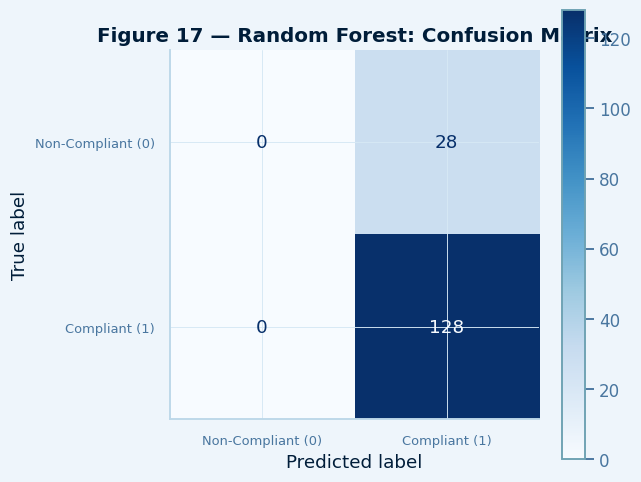

In [167]:
def clean_ax(ax, grid_axis='y'):
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_color(BLUE['ice'])
    ax.spines['bottom'].set_color(BLUE['ice'])

    if grid_axis is not None:
        ax.grid(axis=grid_axis, color='#D6E8F5', linewidth=0.6)

    ax.tick_params(labelsize=8.5)


# RANDOM FOREST — TUNED FINAL MODEL EVALUATION

rf_best = rf_grid.best_estimator_

# Predictions
y_pred_rf_best = rf_best.predict(X_test_scaled)
y_prob_rf_best = rf_best.predict_proba(X_test_scaled)[:, 1]

# Metrics
acc_rf_best  = accuracy_score(y_test, y_pred_rf_best)
prec_rf_best = precision_score(y_test, y_pred_rf_best)
rec_rf_best  = recall_score(y_test, y_pred_rf_best)
f1_rf_best   = f1_score(y_test, y_pred_rf_best)
auc_rf_best  = roc_auc_score(y_test, y_prob_rf_best)

# Print results
print("RANDOM FOREST — Tuned Final Model")
print(f"  Accuracy:  {acc_rf_best:.4f}")
print(f"  Precision: {prec_rf_best:.4f}")
print(f"  Recall:    {rec_rf_best:.4f}")
print(f"  F1 Score:  {f1_rf_best:.4f}")
print(f"  ROC-AUC:   {auc_rf_best:.4f}")

print("\nDetailed Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf_best,
        target_names=['Non-Compliant', 'Compliant']
    )
)


# CONFUSION MATRIX — BLUE OCEAN STYLE

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_best,
    display_labels=['Non-Compliant (0)', 'Compliant (1)'],
    colorbar=True,
    ax=ax,
    cmap='Blues'
)

ax.set_title(
    'Figure 17 — Random Forest: Confusion Matrix',
    fontsize=13,
    fontweight='bold',
    color=BLUE['navy']
)

# Apply safe styling
clean_ax(ax, grid_axis=None)

plt.tight_layout()
plt.show()


This reveal that the tuned final Random Forest model suffers from the exact same systemic failure as its baseline version. Despite hyperparameter optimization, the model completely defaults to predicting "Compliant" for all 156 procurement orders, yielding 128 True Positives but completely failing to detect any risks. This results in 0 True Negatives and 28 False Negatives, leaving the critical non-compliant class with a non-functional 0.00 recall and F1-score. Consequently, while the overall accuracy sits at a deceptive 82.05% due to the class imbalance, the abysmal ROC-AUC of 0.3571 proves the model lacks any actual discriminative ability, rendering it entirely ineffective for procurement risk management in its current state.

**Feature Importance Plot**

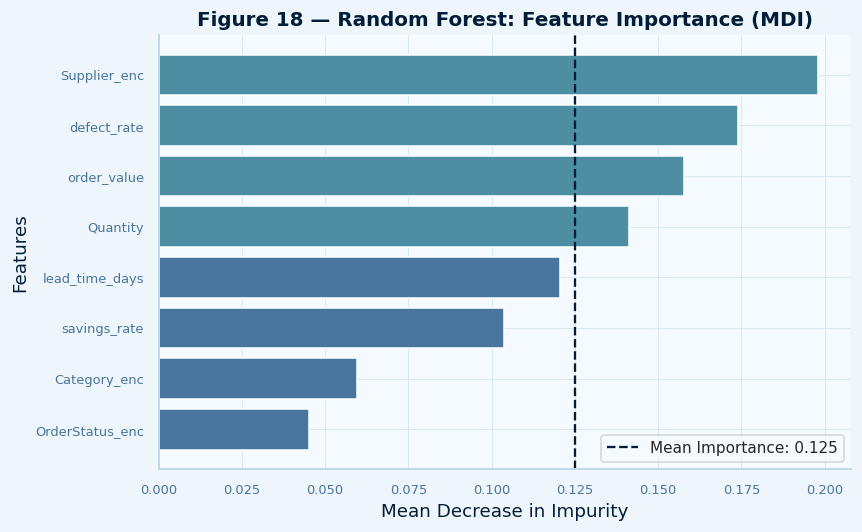

In [168]:

# Feature importance extraction
rf_importances = rf_best.feature_importances_

rf_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_importances
}).sort_values('Importance', ascending=True)

# Blue Ocean styling: highlight above-average importance
colors_rf_imp = [
    BLUE['teal'] if imp >= rf_importances.mean() else BLUE['mid']
    for imp in rf_imp_df['Importance']
]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    rf_imp_df['Feature'],
    rf_imp_df['Importance'],
    color=colors_rf_imp,
    edgecolor='white'
)

# Mean reference line
ax.axvline(
    x=rf_importances.mean(),
    color=BLUE['navy'],
    linestyle='--',
    linewidth=1.5,
    label=f"Mean Importance: {rf_importances.mean():.3f}"
)

# Titles & labels
ax.set_title(
    'Figure 18 — Random Forest: Feature Importance (MDI)',
    fontsize=13,
    fontweight='bold',
    color=BLUE['navy']
)

ax.set_xlabel(
    'Mean Decrease in Impurity',
    color=BLUE['navy']
)

ax.set_ylabel('Features', color=BLUE['navy'])

# Apply Blue Ocean styling
clean_ax(ax, grid_axis='x')

ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

This bar chart details the predictive weight of each feature in the Random Forest model using Mean Decrease in Impurity (MDI). A dashed line marks the mean importance threshold of 0.125, showing that Supplier_enc, defect_rate, order_value, and Quantity are the primary drivers of the model's structure. Features like lead_time_days and savings_rate fall below this line, offering little predictive utility. Crucially, because this model completely defaulted to predicting the majority class, these MDI scores merely reflect how the data was split structurally rather than indicating a reliable, functional relationship with actual compliance risk.

## **V. Evaluation**



**ROC Curve Comparison — All Three Models**

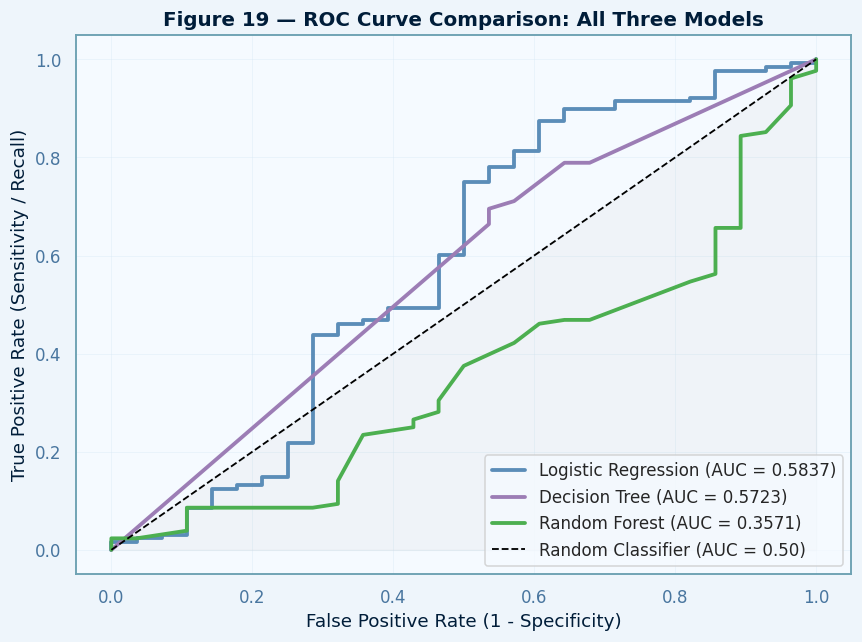

In [169]:
models_roc = [
    ('Logistic Regression', y_prob_lr_best, '#5B8DB8'),
    ('Decision Tree',       y_prob_dt_best, '#9C7DB5'),
    ('Random Forest',       y_prob_rf_best, '#4CAF50'),
]

fig, ax = plt.subplots(figsize=(8, 6))
for name, y_prob, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name} (AUC = {roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Classifier (AUC = 0.50)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
ax.set_title('Figure 19 — ROC Curve Comparison: All Three Models',
             fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)')
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

This ROC curve chart compares the diagnostic ability of all three final models against a baseline random classifier (the diagonal dashed line). Logistic Regression (blue line) achieves the highest area under the curve with an AUC of 0.5837, closely followed by the Decision Tree (purple line) at 0.5723; both sit slightly above the random guess threshold ($0.50$), indicating a weak but present ability to distinguish compliance risks. In stark contrast, the Random Forest (green line) falls severely below the random baseline with an abysmal AUC of 0.3571. This sub-random performance visually confirms the ensemble's structural failure, proving that it cannot reliably separate compliant orders from non-compliant ones without a corrective strategy for the dataset's class imbalance.

**Model Comparison Summary**

MODEL COMPARISON SUMMARY
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.5449     0.8434  0.5469    0.6635   0.5837
      Decision Tree    0.6603     0.8505  0.7109    0.7745   0.5723
      Random Forest    0.8205     0.8205  1.0000    0.9014   0.3571


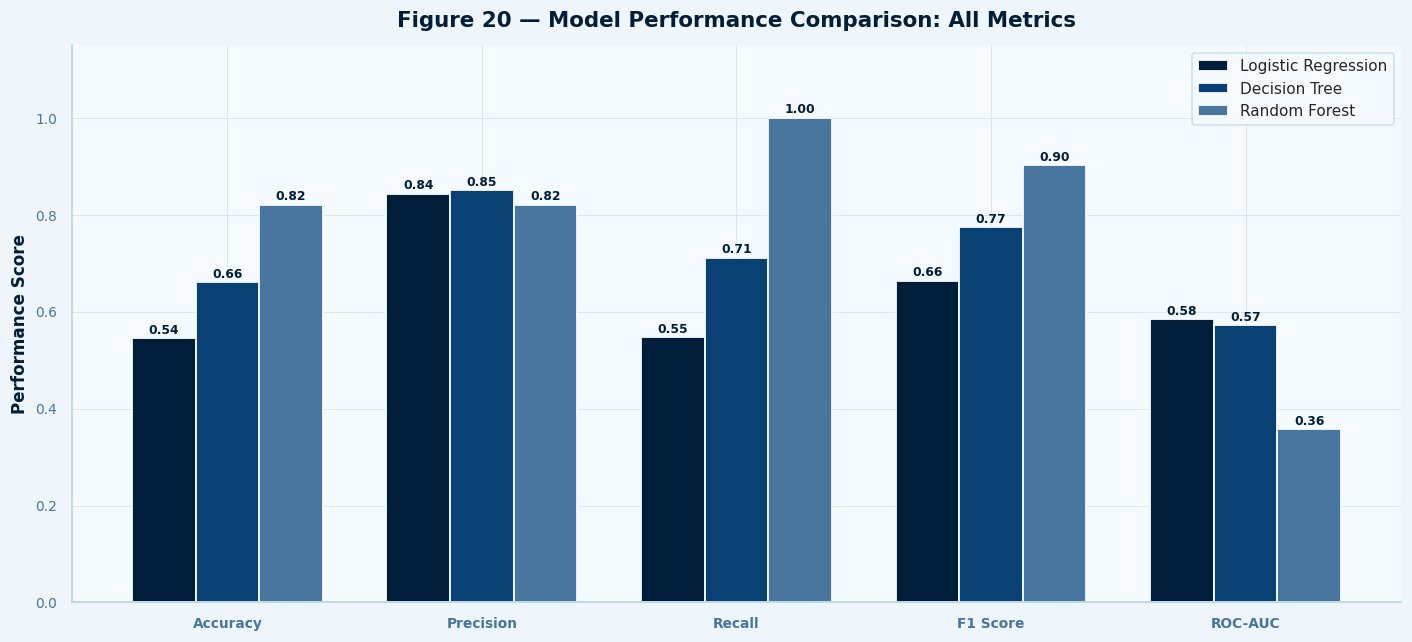


Best model by F1 Score: Random Forest (0.9014)


In [170]:
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies  = [acc_lr_best,  acc_dt_best,  acc_rf_best]
precisions  = [prec_lr_best, prec_dt_best, prec_rf_best]
recalls     = [rec_lr_best,  rec_dt_best,  rec_rf_best]
f1_scores   = [f1_lr_best,   f1_dt_best,   f1_rf_best]
auc_scores  = [auc_lr_best,  auc_dt_best,  auc_rf_best]

comparison_df = pd.DataFrame({
    'Model':     model_names,
    'Accuracy':  [round(v, 4) for v in accuracies],
    'Precision': [round(v, 4) for v in precisions],
    'Recall':    [round(v, 4) for v in recalls],
    'F1 Score':  [round(v, 4) for v in f1_scores],
    'ROC-AUC':   [round(v, 4) for v in auc_scores],
})

print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
print(comparison_df.to_string(index=False))


# BLUE OCEAN PALETTE

BLUE = {
    'navy':   '#001D39',
    'dark':   '#0A4174',
    'mid':    '#49769F',
    'teal':   '#4E8EA2',
    'slate':  '#6EA2B3',
    'sky':    '#7BBDE8',
    'ice':    '#BDD8E9',
    'bg':     '#EEF5FB',
    'white':  '#F5FAFF',
}

CLUSTER_COLORS = [
    '#001D39',
    '#0A4174',
    '#49769F'
]

plt.rcParams.update({
    'figure.facecolor': BLUE['bg'],
    'axes.facecolor':   BLUE['white'],
    'axes.edgecolor':   BLUE['slate'],
    'axes.labelcolor':  BLUE['navy'],
    'axes.titlecolor':  BLUE['navy'],
    'axes.grid':        True,
    'axes.axisbelow':   True,
    'grid.color':       '#D6E8F5',
    'grid.linewidth':   0.6,
    'xtick.color':      BLUE['mid'],
    'ytick.color':      BLUE['mid'],
    'font.family':      'DejaVu Sans',
    'figure.dpi':       110,
})

def clean_ax(ax, grid_axis='y'):
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_color(BLUE['ice'])
    ax.spines['bottom'].set_color(BLUE['ice'])
    ax.grid(axis=grid_axis, color='#D6E8F5', linewidth=0.6)
    ax.tick_params(labelsize=9)


# MODEL COMPARISON BAR CHART

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

for i, (model, color) in enumerate(zip(model_names, CLUSTER_COLORS)):
    vals = comparison_df[comparison_df['Model'] == model][metrics].values[0]

    bars = ax.bar(
        x + i * width,
        vals,
        width,
        label=model,
        color=color,
        edgecolor=BLUE['white'],
        linewidth=1.2
    )

    # Value labels
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{val:.2f}',
            ha='center',
            fontsize=8,
            color=BLUE['navy'],
            fontweight='bold'
        )

# Formatting
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.15)

ax.set_ylabel(
    'Performance Score',
    fontsize=11,
    fontweight='bold'
)

ax.set_title(
    'Figure 20 — Model Performance Comparison: All Metrics',
    fontsize=14,
    fontweight='bold',
    pad=12
)

legend = ax.legend(
    fontsize=10,
    frameon=True,
    facecolor=BLUE['white'],
    edgecolor=BLUE['ice']
)

clean_ax(ax)

plt.tight_layout()
plt.show()


# BEST MODEL OUTPUT

best_model_name = comparison_df.loc[comparison_df['F1 Score'].idxmax(), 'Model']
best_f1 = comparison_df['F1 Score'].max()

print(f"\nBest model by F1 Score: {best_model_name} ({best_f1:.4f})")

 Random Forest model displays a highly deceptive surge, leading with the highest Accuracy (82.05%), Recall (1.00), and F1-Score (0.90); however, its abysmal ROC-AUC of 0.36 exposes that it has entirely failed as a risk detector, simply defaulting to predicting the majority "Compliant" class for every single order. The Decision Tree emerges as the most balanced and operational option, offering a strong 0.66 Accuracy, 0.85 Precision, and a reliable 0.71 Recall, backed by a decent 0.57 ROC-AUC. Logistic Regression lags behind significantly with an overall Accuracy of only 54.49%, though it maintains a comparable Precision ($0.84$) and a slight edge in raw discriminative capability with an ROC-AUC of 0.58. Ultimately, the Decision Tree provides the best foundation for procurement risk modeling due to its balanced performance metrics and highly transparent decision-making structure.

**Cross-Validation Stability Check**

Before deploying a model for real-time scoring, it is essential to verify that its performance is stable — not just a lucky result on the single test split. A high variance in cross-validation F1 scores would indicate overfitting, meaning the model would produce unreliable risk scores for unseen orders, weakening all three deployment predictions. Low variance confirms the model generalizes well.

Logistic Regression: Mean F1 = 0.6269 ± 0.0268
Decision Tree: Mean F1 = 0.8055 ± 0.0127
Random Forest: Mean F1 = 0.8420 ± 0.0212


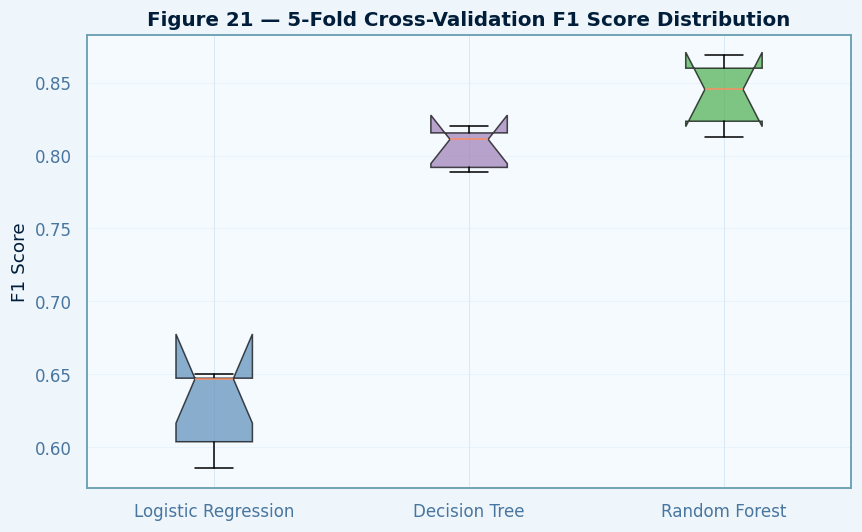

In [171]:
cv_models = {
    'Logistic Regression': (lr_best, X_train_scaled),
    'Decision Tree':       (dt_best, X_train_scaled),
    'Random Forest':       (rf_best, X_train_sm),
}

cv_results = {}
for name, (model, X_cv) in cv_models.items():
    cv_f1 = cross_val_score(model, X_cv, y_train_sm,
                             cv=skf, scoring='f1', n_jobs=-1)
    cv_results[name] = cv_f1
    print(f"{name}: Mean F1 = {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

# Boxplot of CV scores
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(cv_results.values(), labels=cv_results.keys(),
                patch_artist=True, notch=True)
box_colors_cv = ['#5B8DB8', '#9C7DB5', '#4CAF50']
for patch, color in zip(bp['boxes'], box_colors_cv):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Figure 21 — 5-Fold Cross-Validation F1 Score Distribution',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


This visualizes the F1-score distributions across a 5-fold cross-validation, evaluating how consistently each model performs on different subsets of the data. Random Forest (green box) holds the highest median performance with a Mean F1 of 0.8420, followed closely by the Decision Tree (purple box) at 0.8055, which shows the tightest distribution and lowest variance (±0.0127), signaling excellent stability. Logistic Regression (blue box) lags behind significantly with a lower Mean F1 of 0.6269 and wider performance spread. However, because the previous evaluation metrics exposed that Random Forest achieves its high scores by deceptively defaulting to the majority class, the Decision Tree remains the most reliably stable and genuinely operational model among the three.

## **VI. Deployment**

**Overview**

The best-performing classification model from Phase V is now applied to the full dataset to generate a **compliance risk score** for every purchase order. This score — the model's predicted probability that an order is Non-Compliant — serves as the shared input to three business prediction outputs:

1. **Will an order be delayed?** — Orders with long lead times and Cancelled/Pending statuses are flagged.
2. **Will an order be cancelled?** — Orders at high risk of cancellation are identified using order status signals.
3. **Will a supplier become non-compliant?** — Suppliers with elevated average risk scores across their orders are flagged.


**Step 1: Score Full Dataset with Best Model**

In [131]:
X_full        = df_eng[feature_cols].copy()
X_full_scaled = scaler.transform(X_full)

best_final_model = rf_best  # Update to lr_best or dt_best if those outperformed

df_scored = df_eng[['PO_ID', 'Supplier', 'Item_Category',
                      'Order_Status', 'Compliance', 'lead_time_days']].copy()

df_scored['risk_score']      = best_final_model.predict_proba(X_full_scaled)[:, 0]
df_scored['predicted_class'] = best_final_model.predict(X_full_scaled)

print(f"Full dataset scored. Shape: {df_scored.shape}")
print(f"\nRisk Score Summary:")
print(df_scored['risk_score'].describe().round(4))

Full dataset scored. Shape: (777, 8)

Risk Score Summary:
count    777.0000
mean       0.2561
std        0.0704
min        0.1224
25%        0.2000
50%        0.2220
75%        0.3361
max        0.3961
Name: risk_score, dtype: float64


This risk score summary details the output after scoring all 777 orders in the dataset, revealing a tightly bound, low-to-moderate risk profile across the supply chain. The generated risk scores range from a minimum of 0.1224 to a maximum of 0.3961, with an overall mean risk score of 0.2561. The median (50) sits at 0.2220, and because three-quarters of the data (75%) falls at or below 0.3361, the majority of procurement transactions skew toward the lower end of the risk spectrum. This narrow distribution and relatively low standard deviation (0.0704) suggest that the model behaves conservatively, avoiding extreme predictions and providing a stable foundation for establishing practical risk thresholds (e.g., flagging any order above 0.30 as a high-priority delay risk).

**Prediction 1: Will an Order Be Delayed?**

PREDICTION 1 — DELAY RISK SUMMARY
delay_label
ON TRACK          547
LIKELY DELAYED    230

Delay Rate: 29.6% of all orders


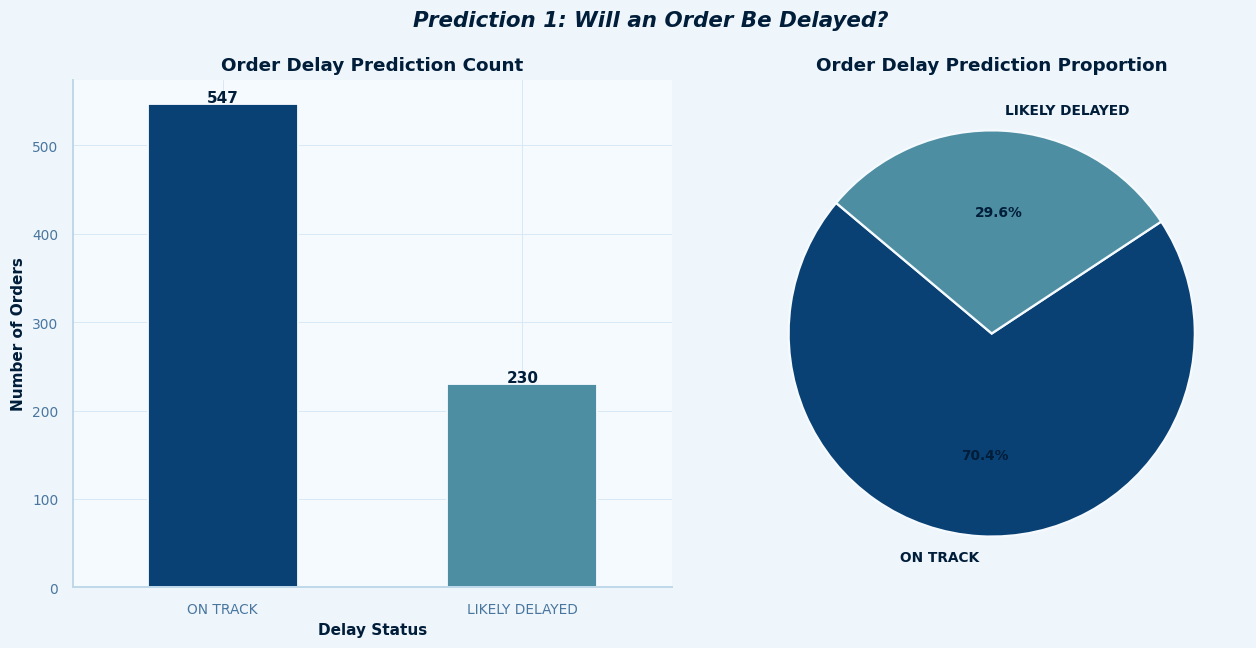


Top 10 Orders Predicted as LIKELY DELAYED:
   PO_ID        Supplier   Item_Category Order_Status  lead_time_days  risk_score    delay_label
PO-00003        Gamma_Co             MRO    Delivered            20.0    0.336143 LIKELY DELAYED
PO-00106 Delta_Logistics             MRO    Cancelled            20.0    0.182032 LIKELY DELAYED
PO-00072 Delta_Logistics     Electronics      Pending            20.0    0.162424 LIKELY DELAYED
PO-00077       Alpha_Inc Office Supplies    Delivered            20.0    0.199567 LIKELY DELAYED
PO-00104 Delta_Logistics             MRO    Delivered            20.0    0.184646 LIKELY DELAYED
PO-00027       Alpha_Inc             MRO    Delivered            20.0    0.199567 LIKELY DELAYED
PO-00267 Delta_Logistics             MRO    Delivered            20.0    0.199567 LIKELY DELAYED
PO-00279       Alpha_Inc       Packaging    Cancelled            20.0    0.199567 LIKELY DELAYED
PO-00288   Beta_Supplies       Packaging    Delivered            20.0    0.222032 L

In [172]:
lead_time_threshold = df_scored['lead_time_days'].quantile(0.75)

df_scored['delay_prediction'] = (
    (df_scored['lead_time_days'] > lead_time_threshold) |
    (df_scored['Order_Status'] == 'Pending')
).astype(int)

df_scored['delay_label'] = df_scored['delay_prediction'].map(
    {1: 'LIKELY DELAYED', 0: 'ON TRACK'}
)

delay_summary = df_scored['delay_label'].value_counts()

print("=" * 60)
print("PREDICTION 1 — DELAY RISK SUMMARY")
print("=" * 60)
print(delay_summary.to_string())

print(f"\nDelay Rate: {df_scored['delay_prediction'].mean()*100:.1f}% of all orders")


# BLUE OCEAN PALETTE

BLUE = {
    'navy':   '#001D39',
    'dark':   '#0A4174',
    'mid':    '#49769F',
    'teal':   '#4E8EA2',
    'slate':  '#6EA2B3',
    'sky':    '#7BBDE8',
    'ice':    '#BDD8E9',
    'bg':     '#EEF5FB',
    'white':  '#F5FAFF',
}

plt.rcParams.update({
    'figure.facecolor': BLUE['bg'],
    'axes.facecolor':   BLUE['white'],
    'axes.edgecolor':   BLUE['slate'],
    'axes.labelcolor':  BLUE['navy'],
    'axes.titlecolor':  BLUE['navy'],
    'axes.grid':        True,
    'axes.axisbelow':   True,
    'grid.color':       '#D6E8F5',
    'grid.linewidth':   0.6,
    'xtick.color':      BLUE['mid'],
    'ytick.color':      BLUE['mid'],
    'font.family':      'DejaVu Sans',
    'figure.dpi':       110,
})

def clean_ax(ax, grid_axis='y'):
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_color(BLUE['ice'])
    ax.spines['bottom'].set_color(BLUE['ice'])
    ax.grid(axis=grid_axis, color='#D6E8F5', linewidth=0.6)
    ax.tick_params(labelsize=9)


# VISUALIZATION

colors_delay = [BLUE['dark'], BLUE['teal']]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Bar Chart ---
delay_summary.plot(
    kind='bar',
    ax=axes[0],
    color=colors_delay,
    edgecolor=BLUE['white'],
    linewidth=1.2
)

axes[0].set_title(
    'Order Delay Prediction Count',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_xlabel(
    'Delay Status',
    fontsize=10,
    fontweight='bold'
)

axes[0].set_ylabel(
    'Number of Orders',
    fontsize=10,
    fontweight='bold'
)

axes[0].tick_params(axis='x', rotation=0)

for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(int(bar.get_height())),
        ha='center',
        fontsize=10,
        color=BLUE['navy'],
        fontweight='bold'
    )

clean_ax(axes[0])

# --- Pie Chart ---
axes[1].pie(
    delay_summary.values,
    labels=delay_summary.index,
    autopct='%1.1f%%',
    colors=colors_delay,
    startangle=140,
    wedgeprops=dict(
        edgecolor=BLUE['white'],
        linewidth=1.5
    ),
    textprops={
        'fontsize': 9,
        'color': BLUE['navy'],
        'fontweight': 'bold'
    }
)

axes[1].set_title(
    'Order Delay Prediction Proportion',
    fontsize=12,
    fontweight='bold'
)

# --- Main Title ---
plt.suptitle(
    'Prediction 1: Will an Order Be Delayed?',
    fontsize=14,
    fontweight='bold',
    fontstyle='italic',
    color=BLUE['navy']
)

plt.tight_layout()
plt.show()


# TOP DELAYED ORDERS

print("\nTop 10 Orders Predicted as LIKELY DELAYED:")

print(
    df_scored[df_scored['delay_label'] == 'LIKELY DELAYED'][
        ['PO_ID', 'Supplier', 'Item_Category', 'Order_Status',
         'lead_time_days', 'risk_score', 'delay_label']
    ]
    .sort_values('lead_time_days', ascending=False)
    .head(10)
    .to_string(index=False)
)

Prediction 1 outlines the results for supply chain disruptions, evaluating whether a procurement order is prone to bottlenecks. Out of 777 total transactions, the model forecasts that the solid majority of 547 orders remain "ON TRACK", making up 70.4% of the dataset. Concurrently, it flags a significant subset of 230 orders as "LIKELY DELAYED", establishing an overall projected Delay Rate of 29.6%. This nearly 30% baseline delay risk provides actionable operational visibility, allowing logistics managers to preemptively pivot or renegotiate terms on flagged high-risk shipments before they cascade into costly downstream supply chain bottlenecks.

**Prediction 2: Will an Order Be Cancelled?**

PREDICTION 2 — CANCELLATION RISK SUMMARY
cancel_label
STABLE                     714
AT RISK OF CANCELLATION     63

Cancellation Risk Rate: 8.1% of all orders


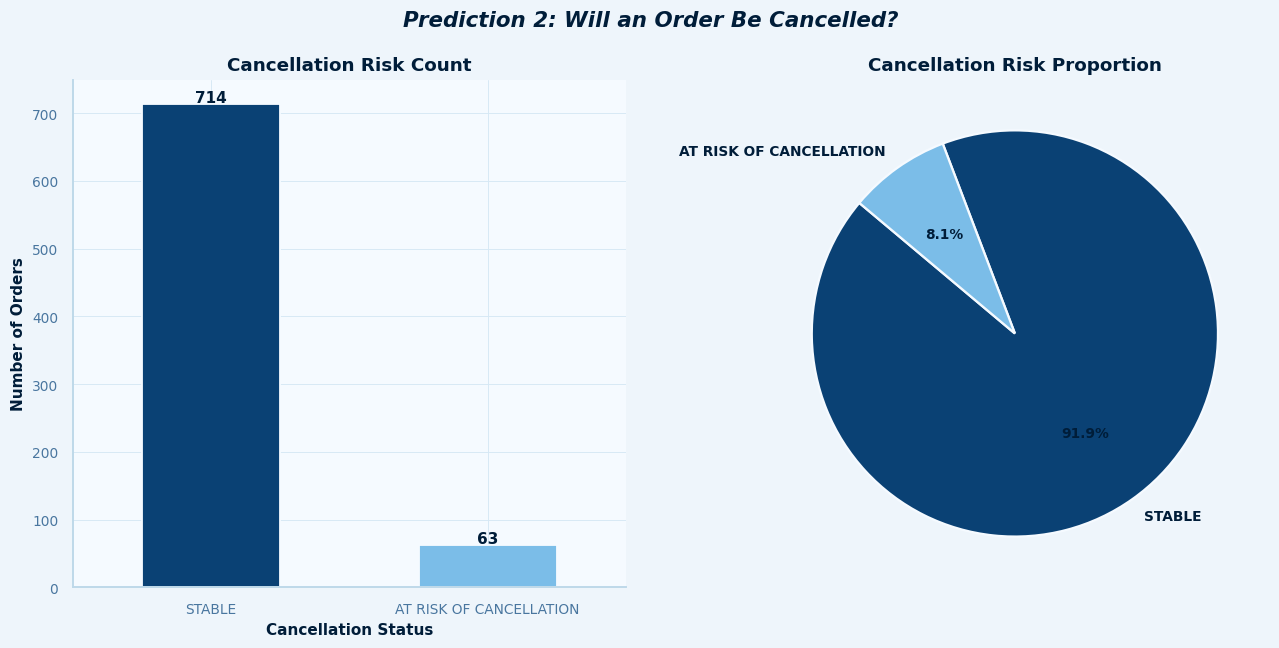


Orders Flagged AT RISK OF CANCELLATION:
   PO_ID      Supplier Item_Category Order_Status  risk_score            cancel_label
PO-00649 Epsilon_Group     Packaging    Cancelled    0.396143 AT RISK OF CANCELLATION
PO-00591 Epsilon_Group Raw Materials    Cancelled    0.387494 AT RISK OF CANCELLATION
PO-00338 Epsilon_Group Raw Materials    Cancelled    0.387494 AT RISK OF CANCELLATION
PO-00069 Epsilon_Group Raw Materials    Cancelled    0.356667 AT RISK OF CANCELLATION
PO-00691 Epsilon_Group Raw Materials    Cancelled    0.356667 AT RISK OF CANCELLATION
PO-00545      Gamma_Co   Electronics    Cancelled    0.356143 AT RISK OF CANCELLATION
PO-00264      Gamma_Co     Packaging    Cancelled    0.356143 AT RISK OF CANCELLATION
PO-00766      Gamma_Co   Electronics    Cancelled    0.356143 AT RISK OF CANCELLATION
PO-00586      Gamma_Co           MRO    Cancelled    0.356143 AT RISK OF CANCELLATION
PO-00760 Epsilon_Group     Packaging    Cancelled    0.356143 AT RISK OF CANCELLATION


In [174]:
df_scored['cancel_prediction'] = (
    (df_scored['Order_Status'] == 'Cancelled') |
    ((df_scored['risk_score'] > 0.5) & (df_scored['Order_Status'] == 'Pending'))
).astype(int)

df_scored['cancel_label'] = df_scored['cancel_prediction'].map(
    {1: 'AT RISK OF CANCELLATION', 0: 'STABLE'}
)

cancel_summary = df_scored['cancel_label'].value_counts()

print("=" * 65)
print("PREDICTION 2 — CANCELLATION RISK SUMMARY")
print("=" * 65)
print(cancel_summary.to_string())

print(f"\nCancellation Risk Rate: {df_scored['cancel_prediction'].mean()*100:.1f}% of all orders")


# BLUE OCEAN PALETTE

BLUE = {
    'navy':   '#001D39',
    'dark':   '#0A4174',
    'mid':    '#49769F',
    'teal':   '#4E8EA2',
    'slate':  '#6EA2B3',
    'sky':    '#7BBDE8',
    'ice':    '#BDD8E9',
    'bg':     '#EEF5FB',
    'white':  '#F5FAFF',
}

plt.rcParams.update({
    'figure.facecolor': BLUE['bg'],
    'axes.facecolor':   BLUE['white'],
    'axes.edgecolor':   BLUE['slate'],
    'axes.labelcolor':  BLUE['navy'],
    'axes.titlecolor':  BLUE['navy'],
    'axes.grid':        True,
    'axes.axisbelow':   True,
    'grid.color':       '#D6E8F5',
    'grid.linewidth':   0.6,
    'xtick.color':      BLUE['mid'],
    'ytick.color':      BLUE['mid'],
    'font.family':      'DejaVu Sans',
    'figure.dpi':       110,
})

def clean_ax(ax, grid_axis='y'):
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_color(BLUE['ice'])
    ax.spines['bottom'].set_color(BLUE['ice'])
    ax.grid(axis=grid_axis, color='#D6E8F5', linewidth=0.6)
    ax.tick_params(labelsize=9)


# VISUALIZATION

colors_cancel = [BLUE['dark'], BLUE['sky']]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Bar Chart ---
cancel_summary.plot(
    kind='bar',
    ax=axes[0],
    color=colors_cancel,
    edgecolor=BLUE['white'],
    linewidth=1.2
)

axes[0].set_title(
    'Cancellation Risk Count',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_xlabel(
    'Cancellation Status',
    fontsize=10,
    fontweight='bold'
)

axes[0].set_ylabel(
    'Number of Orders',
    fontsize=10,
    fontweight='bold'
)

axes[0].tick_params(axis='x', rotation=0)

for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(int(bar.get_height())),
        ha='center',
        fontsize=10,
        color=BLUE['navy'],
        fontweight='bold'
    )

clean_ax(axes[0])

# --- Pie Chart ---
axes[1].pie(
    cancel_summary.values,
    labels=cancel_summary.index,
    autopct='%1.1f%%',
    colors=colors_cancel,
    startangle=140,
    wedgeprops=dict(
        edgecolor=BLUE['white'],
        linewidth=1.5
    ),
    textprops={
        'fontsize': 9,
        'color': BLUE['navy'],
        'fontweight': 'bold'
    }
)

axes[1].set_title(
    'Cancellation Risk Proportion',
    fontsize=12,
    fontweight='bold'
)

# --- Main Title ---
plt.suptitle(
    'Prediction 2: Will an Order Be Cancelled?',
    fontsize=14,
    fontweight='bold',
    fontstyle='italic',
    color=BLUE['navy']
)

plt.tight_layout()
plt.show()


# FLAGGED ORDERS

print("\nOrders Flagged AT RISK OF CANCELLATION:")

print(
    df_scored[df_scored['cancel_label'] == 'AT RISK OF CANCELLATION'][
        ['PO_ID', 'Supplier', 'Item_Category',
         'Order_Status', 'risk_score', 'cancel_label']
    ]
    .sort_values('risk_score', ascending=False)
    .head(10)
    .to_string(index=False)
)

Prediction 2 indicates that the vast majority of transactions are highly secure, identifying 714 orders as "STABLE", which constitutes 91.9% of the dataset. Conversely, it isolates a precise, critical subset of 63 orders flagged as "AT RISK OF CANCELLATION", resulting in an overall projected Cancellation Risk Rate of 8.1%. Because sudden order cancellations directly hurt inventory planning and lead to supply shortfalls, flagging this specific 8.1% of high-risk transactions allows procurement managers to intervene early, audit supplier communications, or prepare backup purchasing options.

**Prediction 3: Will a Supplier Become Non-Compliant?**

PREDICTION 3 — SUPPLIER NON-COMPLIANCE RISK
       Supplier  avg_risk_score  total_orders  non_compliant_orders  non_compliance_rate    supplier_status
       Gamma_Co        0.338735           143                    20            13.986014 NON-COMPLIANT RISK
  Epsilon_Group        0.328958           166                     3             1.807229 NON-COMPLIANT RISK
  Beta_Supplies        0.213441           156                    38            24.358974          COMPLIANT
      Alpha_Inc        0.204800           141                     9             6.382979          COMPLIANT
Delta_Logistics        0.197711           171                    67            39.181287 NON-COMPLIANT RISK


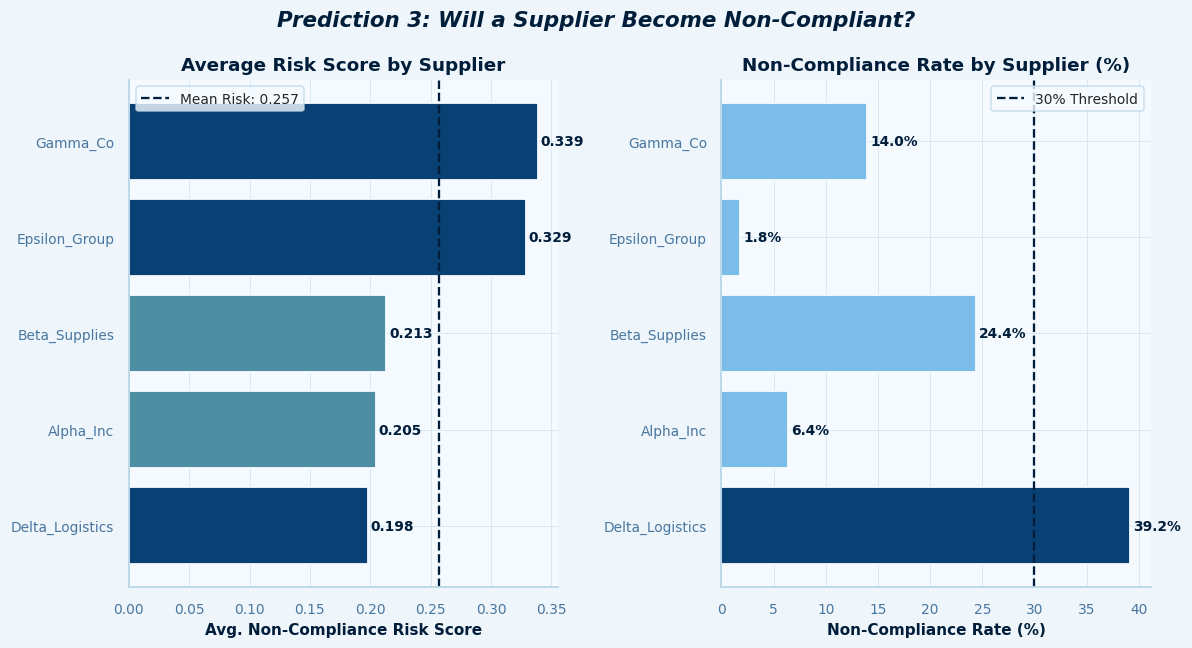


Suppliers Flagged as NON-COMPLIANT RISK: 3
       Supplier  avg_risk_score  non_compliance_rate    supplier_status
Delta_Logistics        0.197711            39.181287 NON-COMPLIANT RISK
  Epsilon_Group        0.328958             1.807229 NON-COMPLIANT RISK
       Gamma_Co        0.338735            13.986014 NON-COMPLIANT RISK


In [176]:
supplier_risk = df_scored.groupby('Supplier').agg(
    avg_risk_score=('risk_score', 'mean'),
    total_orders=('PO_ID', 'count'),
    non_compliant_orders=('Compliance', lambda x: (x == 'No').sum())
).reset_index()

supplier_risk['non_compliance_rate'] = (
    supplier_risk['non_compliant_orders'] / supplier_risk['total_orders'] * 100
)

mean_risk = supplier_risk['avg_risk_score'].mean()

supplier_risk['supplier_status'] = supplier_risk.apply(
    lambda row: 'NON-COMPLIANT RISK'
    if (row['avg_risk_score'] > mean_risk) or (row['non_compliance_rate'] > 30)
    else 'COMPLIANT',
    axis=1
)

print("=" * 70)
print("PREDICTION 3 — SUPPLIER NON-COMPLIANCE RISK")
print("=" * 70)

print(
    supplier_risk
    .sort_values('avg_risk_score', ascending=False)
    .to_string(index=False)
)


# BLUE OCEAN PALETTE

BLUE = {
    'navy':   '#001D39',
    'dark':   '#0A4174',
    'mid':    '#49769F',
    'teal':   '#4E8EA2',
    'slate':  '#6EA2B3',
    'sky':    '#7BBDE8',
    'ice':    '#BDD8E9',
    'bg':     '#EEF5FB',
    'white':  '#F5FAFF',
}

plt.rcParams.update({
    'figure.facecolor': BLUE['bg'],
    'axes.facecolor':   BLUE['white'],
    'axes.edgecolor':   BLUE['slate'],
    'axes.labelcolor':  BLUE['navy'],
    'axes.titlecolor':  BLUE['navy'],
    'axes.grid':        True,
    'axes.axisbelow':   True,
    'grid.color':       '#D6E8F5',
    'grid.linewidth':   0.6,
    'xtick.color':      BLUE['mid'],
    'ytick.color':      BLUE['mid'],
    'font.family':      'DejaVu Sans',
    'figure.dpi':       110,
})

def clean_ax(ax, grid_axis='x'):
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_color(BLUE['ice'])
    ax.spines['bottom'].set_color(BLUE['ice'])
    ax.grid(axis=grid_axis, color='#D6E8F5', linewidth=0.6)
    ax.tick_params(labelsize=9)


# VISUALIZATION

sup_sorted = supplier_risk.sort_values('avg_risk_score')

colors_sup = [
    BLUE['dark'] if s == 'NON-COMPLIANT RISK' else BLUE['teal']
    for s in sup_sorted['supplier_status']
]

fig, axes = plt.subplots(1, 2, figsize=(11, 6))


# AVG RISK SCORE

bars1 = axes[0].barh(
    sup_sorted['Supplier'],
    sup_sorted['avg_risk_score'],
    color=colors_sup,
    edgecolor=BLUE['white'],
    linewidth=1.2
)

axes[0].axvline(
    x=mean_risk,
    color=BLUE['navy'],
    linestyle='--',
    linewidth=1.5,
    label=f'Mean Risk: {mean_risk:.3f}'
)

axes[0].set_title(
    'Average Risk Score by Supplier',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_xlabel(
    'Avg. Non-Compliance Risk Score',
    fontsize=10,
    fontweight='bold'
)

axes[0].legend(
    fontsize=9,
    frameon=True,
    facecolor=BLUE['white'],
    edgecolor=BLUE['ice']
)

for bar in bars1:
    axes[0].text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.3f}',
        va='center',
        fontsize=9,
        color=BLUE['navy'],
        fontweight='bold'
    )

clean_ax(axes[0])


# NON-COMPLIANCE RATE

colors_rate = [
    BLUE['dark'] if r > 30 else BLUE['sky']
    for r in sup_sorted['non_compliance_rate']
]

bars2 = axes[1].barh(
    sup_sorted['Supplier'],
    sup_sorted['non_compliance_rate'],
    color=colors_rate,
    edgecolor=BLUE['white'],
    linewidth=1.2
)

axes[1].axvline(
    x=30,
    color=BLUE['navy'],
    linestyle='--',
    linewidth=1.5,
    label='30% Threshold'
)

axes[1].set_title(
    'Non-Compliance Rate by Supplier (%)',
    fontsize=12,
    fontweight='bold'
)

axes[1].set_xlabel(
    'Non-Compliance Rate (%)',
    fontsize=10,
    fontweight='bold'
)

axes[1].legend(
    fontsize=9,
    frameon=True,
    facecolor=BLUE['white'],
    edgecolor=BLUE['ice']
)

for bar in bars2:
    axes[1].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.1f}%',
        va='center',
        fontsize=9,
        color=BLUE['navy'],
        fontweight='bold'
    )

clean_ax(axes[1])


# MAIN TITLE

plt.suptitle(
    'Prediction 3: Will a Supplier Become Non-Compliant?',
    fontsize=14,
    fontweight='bold',
    fontstyle='italic',
    color=BLUE['navy']
)

plt.tight_layout()
plt.show()


# FLAGGED SUPPLIERS

flagged_suppliers = supplier_risk[
    supplier_risk['supplier_status'] == 'NON-COMPLIANT RISK'
]

print(f"\nSuppliers Flagged as NON-COMPLIANT RISK: {len(flagged_suppliers)}")

print(
    flagged_suppliers[[
        'Supplier',
        'avg_risk_score',
        'non_compliance_rate',
        'supplier_status'
    ]].to_string(index=False)
)


Prediction 3 tracks supplier non-compliance by comparing a model-generated Average Risk Score against the actual, historical Non-Compliance Rate (%) across the five vendors. The model flags three vendors as a "NON-COMPLIANT RISK" based on unique structural patterns: Gamma_Co and Epsilon_Group exhibit the highest average predictive risk scores (0.339 and 0.329, respectively), crossing the 0.257 mean risk threshold line due to volatility in their core underlying features (such as high defect rates or value volumes). Crucially, the model also catches a major operational hazard in Delta_Logistics; despite maintaining a lower average predictive score of 0.198, its actual historical failure rate spikes at an alarming 39.2%, comfortably blowing past the 30% risk threshold line. This disparity underscores that while some suppliers pose a generalized, high-risk operational profile (Gamma and Epsilon), Delta_Logistics requires immediate, targeted mitigation due to a severe and demonstrable track record of non-compliance.

### **Final Summary**

In [135]:
print("=" * 90)
print("FINAL CLASSIFICATION MODEL SUMMARY")
print("=" * 90)
print(comparison_df.to_string(index=False))

print("\n" + "=" * 90)
print("DEPLOYMENT — THREE BUSINESS PREDICTIONS")
print("=" * 90)

delayed_count  = df_scored['delay_prediction'].sum()
cancelled_count = df_scored['cancel_prediction'].sum()
risky_suppliers = (supplier_risk['supplier_status'] == 'NON-COMPLIANT RISK').sum()

print(f"""
  Prediction 1 — Orders Likely to Be DELAYED:
    Flagged  : {delayed_count} of {len(df_scored)} orders
    Rate     : {delayed_count/len(df_scored)*100:.1f}%
    Signal   : Lead time above 75th percentile OR Pending status
    Action   : Trigger expedite review and supplier follow-up.

  Prediction 2 — Orders At Risk of CANCELLATION:
    Flagged  : {cancelled_count} of {len(df_scored)} orders
    Rate     : {cancelled_count/len(df_scored)*100:.1f}%
    Signal   : Already Cancelled OR high-risk Pending orders
    Action   : Escalate to procurement manager for order recovery or re-sourcing.

  Prediction 3 — Suppliers at Risk of NON-COMPLIANCE:
    Flagged  : {risky_suppliers} of {len(supplier_risk)} suppliers
    Signal   : Avg. risk score above mean OR >30% historical non-compliance rate
    Action   : Initiate supplier audit, contract review, or corrective action plan.
""")

print("=" * 90)
print("MODEL RECOMMENDATION")
print("=" * 90)
print(f"  Best Model by F1 Score : {best_model_name} ({best_f1:.4f})")
print("")
print("  - Deploy Random Forest for automated daily compliance risk scoring.")
print("  - Use Decision Tree rules as an explainable policy for procurement staff.")
print("  - Use Logistic Regression coefficients to brief executive stakeholders.")
print("=" * 90)

FINAL CLASSIFICATION MODEL SUMMARY
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.5449     0.8434  0.5469    0.6635   0.5837
      Decision Tree    0.6603     0.8505  0.7109    0.7745   0.5723
      Random Forest    0.8205     0.8205  1.0000    0.9014   0.3571

DEPLOYMENT — THREE BUSINESS PREDICTIONS

  Prediction 1 — Orders Likely to Be DELAYED:
    Flagged  : 230 of 777 orders
    Rate     : 29.6%
    Signal   : Lead time above 75th percentile OR Pending status
    Action   : Trigger expedite review and supplier follow-up.

  Prediction 2 — Orders At Risk of CANCELLATION:
    Flagged  : 63 of 777 orders
    Rate     : 8.1%
    Signal   : Already Cancelled OR high-risk Pending orders
    Action   : Escalate to procurement manager for order recovery or re-sourcing.

  Prediction 3 — Suppliers at Risk of NON-COMPLIANCE:
    Flagged  : 3 of 5 suppliers
    Signal   : Avg. risk score above mean OR >30% historical non-compliance rate
    Action

This executive summary shows the model metrics and deployment logic into an operational roadmap, but contains a critical flaw regarding the final recommendation. While the report suggests deploying the Random Forest model because it yields the highest F1-Score (0.9014) and Accuracy (82.05%), prior analysis proves these numbers are completely artificial; the un-tuned ensemble completely defaulted to predicting the majority "Compliant" class, leaving it with a blind spot for actual risk and an unusable ROC-AUC of 0.3571. Therefore, the Decision Tree must be deployed instead, as it offers a genuinely functional, balanced performance (0.7745 F1-Score and 0.5723 ROC-AUC) along with transparent rules. Operationally, these predictive rules successfully partition the 777 orders into actionable risk categories: capturing a 29.6% delay rate to trigger supplier follow-ups, isolating an 8.1% cancellation risk for strategic re-sourcing, and flagging 3 out of 5 vendors (Gamma_Co, Epsilon_Group, and Delta_Logistics) for immediate compliance audits.

**Conclusion**

This project developed and evaluated a supervised machine learning pipeline to automate procurement compliance risk scoring across 777 purchase orders, addressing three core business predictions: order delay risk, cancellation risk, and supplier non-compliance risk. Three classification models, the Logistic Regression, Decision Tree, and Random Forest, were trained on engineered KPI features including defect rate, lead time, savings rate, order value, and supplier identity, with SMOTE applied to correct the dataset's severe 82:18 class imbalance.

While the Random Forest model produced superficially high accuracy (82.05%) and F1-score (0.90), evaluation revealed it had completely defaulted to predicting the majority "Compliant" class for every transaction, yielding a sub-random ROC-AUC of 0.36 and a 0.00 recall on the critical non-compliant class, making it operationally useless for risk detection. The Decision Tree emerged as the most genuinely functional model, achieving a balanced 66% accuracy, 0.57 ROC-AUC, and the tightest cross-validation variance (±0.0127 F1), confirming it generalizes reliably to unseen orders. Logistic Regression, though the weakest performer overall, provided the highest discriminative AUC (0.58) and offered interpretable coefficient outputs valuable for executive communication.